# 1. Load Data

In [2]:
"""Cluster Latent Space

Structure:
    1.1. Imports, Variables, Functions
    1.2. Load Data
"""

# 1.1 Imports, Variables, Functions
# imports
import sys

sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys

sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io

logging.basicConfig(level=logging.INFO)
import importlib
import scanpy as sc
from src.utils import utils

importlib.reload(ut)
importlib.reload(vz)


# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05")
run_dir = os.path.join("..", "..", "outputs", "run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01")
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_type = "ft"
metric = "correlation"  # cosine or correlation

assert embedding_type in ["ft", "pt", "raw", "raw_normed"]
if embedding_type == "ft":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(
        "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
    )
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(
        "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
    )


# functions
def get_counts(df: pd.DataFrame, rel_map: Dict, key_interest: str) -> pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = (
        [],
        [],
        [],
        [],
        [],
        [],
    )
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)  # absolute count of the exact disease
        rel = sum(
            1 for x in topk if x in related
        )  # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel

        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related) + 1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"] = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"] = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"] = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"] = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]

    df_query["old_prec@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_total"
    ]
    df_query["old_recall@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_universe_related"
    ]
    df_query["prec@k"] = (df_query["n_rel_uniq"] + df_query["n_same_uniq"]) / df_query[
        "n_total_unique"
    ]
    df_query["recall@k"] = (
        df_query["n_rel_uniq"] + df_query["n_same_uniq"]
    ) / df_query["n_universe_related"]

    return df_query


# 1.2 Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT

In [3]:
split_idx = 0

# load all adata
adata_test = sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)
adata_valid = sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)
adata_train = sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)

In [4]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    print(f"Loaded ft embeddings from all_outputs")
elif embedding_type == "pt":
    # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
    # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
    # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
    # embeddings_test = pt_adata_test.obsm["X_scGPT"]
    # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
    # embeddings_train = pt_adata_train.obsm["X_scGPT"]

    embeddings_test = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "test-pt_embeddings.npy",
        )
    )
    embeddings_valid = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "valid-pt_embeddings.npy",
        )
    )
    embeddings_train = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "train-pt_embeddings.npy",
        )
    )
    print(f"Loaded pt embeddings from npy files")
elif embedding_type == "raw":
    embeddings_test = np.array(adata_test.X)
    embeddings_valid = np.array(adata_valid.X)
    embeddings_train = np.array(adata_train.X)

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
    print(f"Loaded raw embeddings from adata.X")

elif embedding_type == "raw_normed":
    embeddings_test = np.array(adata_test.layers["X_normed"])
    embeddings_valid = np.array(adata_valid.layers["X_normed"])
    embeddings_train = np.array(adata_train.layers["X_normed"])

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

    print(f"Loaded raw normalized embeddings from adata.X")

Using ft embeddings
Loaded ft embeddings from all_outputs


In [5]:
# Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}")

# Load IC based similarity
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

Loaded universe of disease pairs: 70442515


In [6]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(
    f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}"
)


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}"
)
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}"
)
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [8]:
# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | set(
            _do_df.loc[_do_df["do2"] == d, "do1"]
        )

In [9]:
_do_df = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")

lin_map = dict()
for _,row in _do_df.iterrows():
    do1 = row["do1"]
    do2 = row["do2"]
    lin = row["lin"] 
    if do1 not in lin_map:
        lin_map[do1] = dict()
    if do2 not in lin_map:
        lin_map[do2] = dict()
    lin_map[do1][do2] = lin
    lin_map[do2][do1] = lin

In [10]:
# load embeddings
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

elif embedding_type == "raw":
    embeddings_test = adata_test.X
    embeddings_valid = adata_valid.X
    embeddings_train = adata_train.X

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

elif embedding_type == "raw_normed":
    embeddings_test = adata_test.layers["X_normed"]
    embeddings_valid = adata_valid.layers["X_normed"]
    embeddings_train = adata_train.layers["X_normed"]

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)



# 2. Evaluate Tissue Bias

In [13]:
# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
from tqdm import tqdm

# variable


# functions

def get_tiss_idxs_pairs(uniq_tiss:List[Tuple], tiss_ids:List, datasets:List=None, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    # remove nan tissue if present
    uniq_tiss.remove("nan") if "nan" in uniq_tiss else None

    universe_pairs = list()
    l_weights = list()  # label weights
    for tiss_i in tqdm(uniq_tiss):
        
        # retrieve tissue idxs pairs
        idx1 = np.where(tiss_ids == tiss_i)[0]

        # compute idx combinations
        idx_pairs = list(itertools.combinations(idx1, 2))

        # if ONLY take into account tisseases DIFFERENT datasets
        #! NOTE - BEST WAY TO REMOVE SAME DATASETS - SHOULD BE APPLIED ALWAYS
        if datasets is not None:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([f"{tiss_i}"] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs
    
def get_tiss_idxs_pairs_split(uniq_tiss:List, do_ids_1:List, do_ids_2:List, datasets_1:List=None, datasets_2:List=None, do_diff_dt:bool=True, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    # remove nan tissue if present
    uniq_tiss.remove("nan") if "nan" in uniq_tiss else None

    # make sure do_ids_1 & do_ids_2 are arrays
    do_ids_1 = np.array(do_ids_1)
    do_ids_2 = np.array(do_ids_2)

    universe_pairs = list()
    l_weights = list()  # label weights

    for tiss_i in tqdm(uniq_tiss):
        
        idx1_1 = np.where(do_ids_1 == tiss_i)[0]    # idxs disease a in split 1
        idx1_2 = np.where(do_ids_2 == tiss_i)[0]    # idxs disease b in split 2

        # compute idx combinations disease a 
        idx_pairs = list(itertools.product(idx1_1, idx1_2))

        # if ONLY take into account diseases DIFFERENT datasets
        #! NOTE - BEST WAY TO REMOVE SAME DATASETS - SHOULD BE APPLIED ALWAYS
        if do_diff_dt:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets_1[p[0]] != datasets_2[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([tiss_i] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs
    
def get_random_pairs(n_pairs, N, random_state=42):
    rng = np.random.default_rng(random_state)
    pairs = np.array([rng.choice(N, size=2, replace=False) for _ in range(n_pairs)])
    return pairs

def get_random_pairs_split(n_pairs, N1, N2, random_state=42):
    rng = np.random.default_rng(random_state)
    a = rng.choice(N1, size=n_pairs, replace=True)
    b = rng.choice(N2, size=n_pairs, replace=True)
    pairs = np.array(list(zip(a,b)))
    return np.array(pairs)

def _convert_labels_to_weights(labels: List[str]) -> List[float]:
    """Convert labels to weights"""
    counts = Counter(labels)
    w = np.array([1.0 / counts[d] for d in labels], dtype=float)
    w /= w.sum()                               # normalize to sum to 1
    return w



# Compute Similarity Matrices
# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, metric)
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, metric)
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, metric)

# compute cosine similarity between sets
c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, metric)
c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, metric)

# define dataframers - ease of use
df_train = adata_train.obs.reset_index(drop=True)
df_valid = adata_valid.obs.reset_index(drop=True)
df_test = adata_test.obs.reset_index(drop=True)

In [55]:
from tqdm import tqdm
s_matrix_train = list()

for d1 in tqdm(df_train["doid_id"].to_list()):
    _s_row = list()
    for d2 in df_train["doid_id"].to_list():
        if (d1 == d2):
            _s_row.append(1)
        elif (d1 == "Control") & (d2 != "Control"):
            _s_row.append(0)
        elif (d1 != "Control") & (d2 == "Control"):
            _s_row.append(0)
        else:
            _s_row.append(lin_map[d1][d2])
    s_matrix_train.append(_s_row)
    
s_matrix_train = np.array(s_matrix_train)
print(s_matrix_train.shape)

100%|██████████| 18305/18305 [00:40<00:00, 455.47it/s]


[[1.         0.         1.         ... 0.         1.         0.        ]
 [0.         1.         0.         ... 1.         0.         0.06646701]
 [1.         0.         1.         ... 0.         1.         0.        ]
 ...
 [0.         1.         0.         ... 1.         0.         0.06646701]
 [1.         0.         1.         ... 0.         1.         0.        ]
 [0.         0.06646701 0.         ... 0.06646701 0.         1.        ]]


AttributeError: 'Series' object has no attribute 'tonumpy'

In [ ]:
_idx_ctrl = np.argwhere(df_train["doid_id"].to_numpy() == "Control" ).flatten()
_idx_dis = np.argwhere(df_train["doid_id"].to_numpy() != "Control").flatten()

In [57]:
_dts = df_train["dataset"].to_numpy()

pairs = list(itertools.permutations(_idx_dis, 2))
# exclude same dataset pairs
pairs_dts_diff = [p for p in pairs if _dts[p[0]] != _dts[p[1]]]

print(f"Nº of pairs universe: {len(pairs)}\t Nº of pairs diff. datasets {len(pairs_dts_diff)}")

Nº of pairs universe: 139771506	 Nº of pairs diff. datasets 137346860


In [ ]:
_idxs_all = np.array(list(range(len(df_train))))

pairs_all = list(itertools.permutations(_idx_dis, 2))

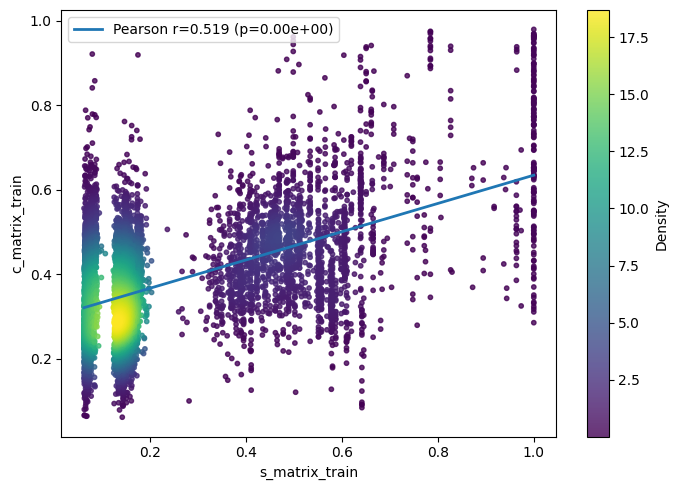

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr
import random

_rnd_idxs = np.array(random.sample(pairs_dts_diff, 10000))

x = s_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]
y = c_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]

# --- density (KDE)
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)   # density for each point

# sort so dense points are plotted last (on top)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.figure(figsize=(7, 5))
sc = plt.scatter(x, y, c=z, s=10, alpha=0.8)
plt.colorbar(sc, label="Density")

# --- correlation + regression line
r, p = pearsonr(x, y)
m, b = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, m * xx + b, linewidth=2, label=f"Pearson r={r:.3f} (p={p:.2e})")

plt.xlabel("s_matrix_train")
plt.ylabel("c_matrix_train")
plt.legend()
plt.tight_layout()
plt.show()


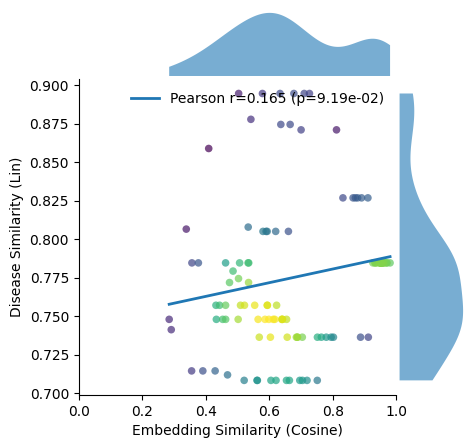

In [101]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr

thr = [0.7,0.9]

# --- sample indices
_rnd_idxs = np.array(random.sample(pairs_dts_diff, 10000))

y = s_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]
x = c_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]

mask = (y >= thr[0]) & (y <= thr[1])
x = x[mask]
y = y[mask]


# --- density for scatter coloring (2D KDE)
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# plot dense points on top
idx = np.argsort(z)
x, y, z = x[idx], y[idx], z[idx]

# --- correlation + regression
r, p = pearsonr(x, y)
m, b = np.polyfit(x, y, 1)

# --- layout: joint plot with tight marginals
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=(5, 1.1),
    height_ratios=(1.1, 5),
    wspace=0.0,   # as close as possible
    hspace=0.0
)

ax_top   = fig.add_subplot(gs[0, 0])
ax_joint = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

# --- main scatter (no colorbar)
ax_joint.scatter(x, y, c=z, s=30, alpha=0.7, linewidths=0)

# regression line
xx = np.linspace(x.min(), x.max(), 200)
ax_joint.plot(xx, m * xx + b, linewidth=2,
              label=f"Pearson r={r:.3f} (p={p:.2e})")

ax_joint.set_xlabel("Embedding Similarity (Cosine)")
ax_joint.set_ylabel("Disease Similarity (Lin)")
ax_joint.legend(frameon=False)

ax_joint.set_xlim(0,1)

# --- marginal KDEs (filled)
x_grid = np.linspace(x.min(), x.max(), 400)
y_grid = np.linspace(y.min(), y.max(), 400)

kde_x = gaussian_kde(x)
kde_y = gaussian_kde(y)

dens_x = kde_x(x_grid)
dens_y = kde_y(y_grid)

ax_top.fill_between(x_grid, dens_x, alpha=0.6)
ax_right.fill_betweenx(y_grid, dens_y, alpha=0.6)

# match limits so marginals align perfectly
ax_top.set_xlim(ax_joint.get_xlim())
ax_right.set_ylim(ax_joint.get_ylim())

# --- remove all marginal axis decorations
for ax in (ax_top, ax_right):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)

# --- remove touching spines to make panels blend
ax_joint.spines["top"].set_visible(False)
ax_joint.spines["right"].set_visible(False)

plt.show()


In [49]:
s_matrix_train

array([[0.        ],
       [0.06646701],
       [0.        ],
       ...,
       [0.06646701],
       [0.        ],
       [1.        ]], shape=(18305, 1))

In [44]:
_rnd_idxs

array([[108, 112],
       [ 75, 132],
       [ 30,  83],
       [ 73,   1],
       [ 40,  84],
       [ 14,  64],
       [  8, 101],
       [ 92, 116],
       [  4,  72],
       [ 27,  82],
       [ 34,  65],
       [ 44, 105],
       [ 58, 117],
       [ 77, 102],
       [ 14,  73],
       [  8,  19],
       [ 51,  36],
       [ 30,  74],
       [148,   1],
       [  1,   5],
       [106,  53],
       [134, 117],
       [118,  51],
       [132, 122],
       [ 13,  52],
       [113,  15],
       [ 94,   1],
       [ 66, 112],
       [ 92, 105],
       [ 59, 137],
       [147,  90],
       [115,  33],
       [ 58,  35],
       [  8, 112],
       [ 78, 109],
       [ 78, 116],
       [ 13, 132],
       [ 18,  39],
       [ 82,   8],
       [118, 132],
       [ 10,  88],
       [ 90, 108],
       [107,  82],
       [ 81,  35],
       [101,  83],
       [101,  73],
       [125, 108],
       [  5,  47],
       [ 47, 133],
       [ 33,  12],
       [137, 109],
       [ 12,  38],
       [  5,

In [28]:
pairs_dts_diff

[(array([1]), array([4])),
 (array([1]), array([5])),
 (array([1]), array([6])),
 (array([1]), array([7])),
 (array([1]), array([8])),
 (array([1]), array([10])),
 (array([1]), array([12])),
 (array([1]), array([13])),
 (array([1]), array([14])),
 (array([1]), array([15])),
 (array([1]), array([16])),
 (array([1]), array([17])),
 (array([1]), array([18])),
 (array([1]), array([19])),
 (array([1]), array([23])),
 (array([1]), array([25])),
 (array([1]), array([27])),
 (array([1]), array([29])),
 (array([1]), array([30])),
 (array([1]), array([31])),
 (array([1]), array([33])),
 (array([1]), array([34])),
 (array([1]), array([35])),
 (array([1]), array([36])),
 (array([1]), array([38])),
 (array([1]), array([39])),
 (array([1]), array([40])),
 (array([1]), array([41])),
 (array([1]), array([43])),
 (array([1]), array([44])),
 (array([1]), array([47])),
 (array([1]), array([48])),
 (array([1]), array([51])),
 (array([1]), array([52])),
 (array([1]), array([53])),
 (array([1]), array([58])

In [ ]:
s_matrix_train[_rnd_idxs]

(10000, 2, 1, 1)

In [27]:
_rnd_idxs

array([[[18061],
        [10572]],

       [[ 1227],
        [13348]],

       [[ 2263],
        [ 4950]],

       ...,

       [[  648],
        [ 8625]],

       [[10285],
        [18067]],

       [[12201],
        [15246]]], shape=(10000, 2, 1))

In [ ]:
itertools.pair

In [ ]:
lin_map["Control"]

KeyError: 'Control'

In [ ]:
do_df_ic

In [ ]:
# get tissue idxs pairs & weights
tr_idx, tr_l = get_tiss_idxs_pairs(df_train["tissue"].unique().tolist(),
                   df_train["tissue"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   return_weights=True)

vl_idx, vl_l = get_tiss_idxs_pairs_split(df_valid["tissue"].unique().tolist(),
                   df_valid["tissue"].to_numpy(),
                   df_train["tissue"].to_numpy(),
                   df_valid["dataset"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   return_weights=True)


ts_idx, ts_l = get_tiss_idxs_pairs_split(df_test["tissue"].unique().tolist(),
                   df_test["tissue"].to_numpy(),
                   df_train["tissue"].to_numpy(),
                   df_test["dataset"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   return_weights=True)

ts_w = _convert_labels_to_weights(ts_l)
vl_w = _convert_labels_to_weights(vl_l)
tr_w = _convert_labels_to_weights(tr_l)

# get random pairs
tr_idx_rand = get_random_pairs(len(tr_idx), df_train.shape[0], random_state=42)
vl_idx_rand = get_random_pairs_split(len(vl_idx),  df_valid.shape[0],df_train.shape[0], random_state=42)
ts_idx_rand = get_random_pairs_split(len(ts_idx), df_test.shape[0], df_train.shape[0], random_state=42)

# get similarities
tr_s_tiss = c_matrix_train[tr_idx[:,0], tr_idx[:,1]]
tr_s_rand = c_matrix_train[tr_idx_rand[:,0], tr_idx_rand[:,1]]

vl_s_tiss = c_matrix_valid_vs_train[vl_idx[:,0], vl_idx[:,1]]
vl_s_rand = c_matrix_valid_vs_train[vl_idx_rand[:,0], vl_idx_rand[:,1]]

ts_s_tiss = c_matrix_test_vs_train[ts_idx[:,0], ts_idx[:,1]]
ts_s_rand = c_matrix_test_vs_train[ts_idx_rand[:,0], ts_idx_rand[:,1]]


100%|██████████| 38/38 [00:00<00:00, 187.01it/s]


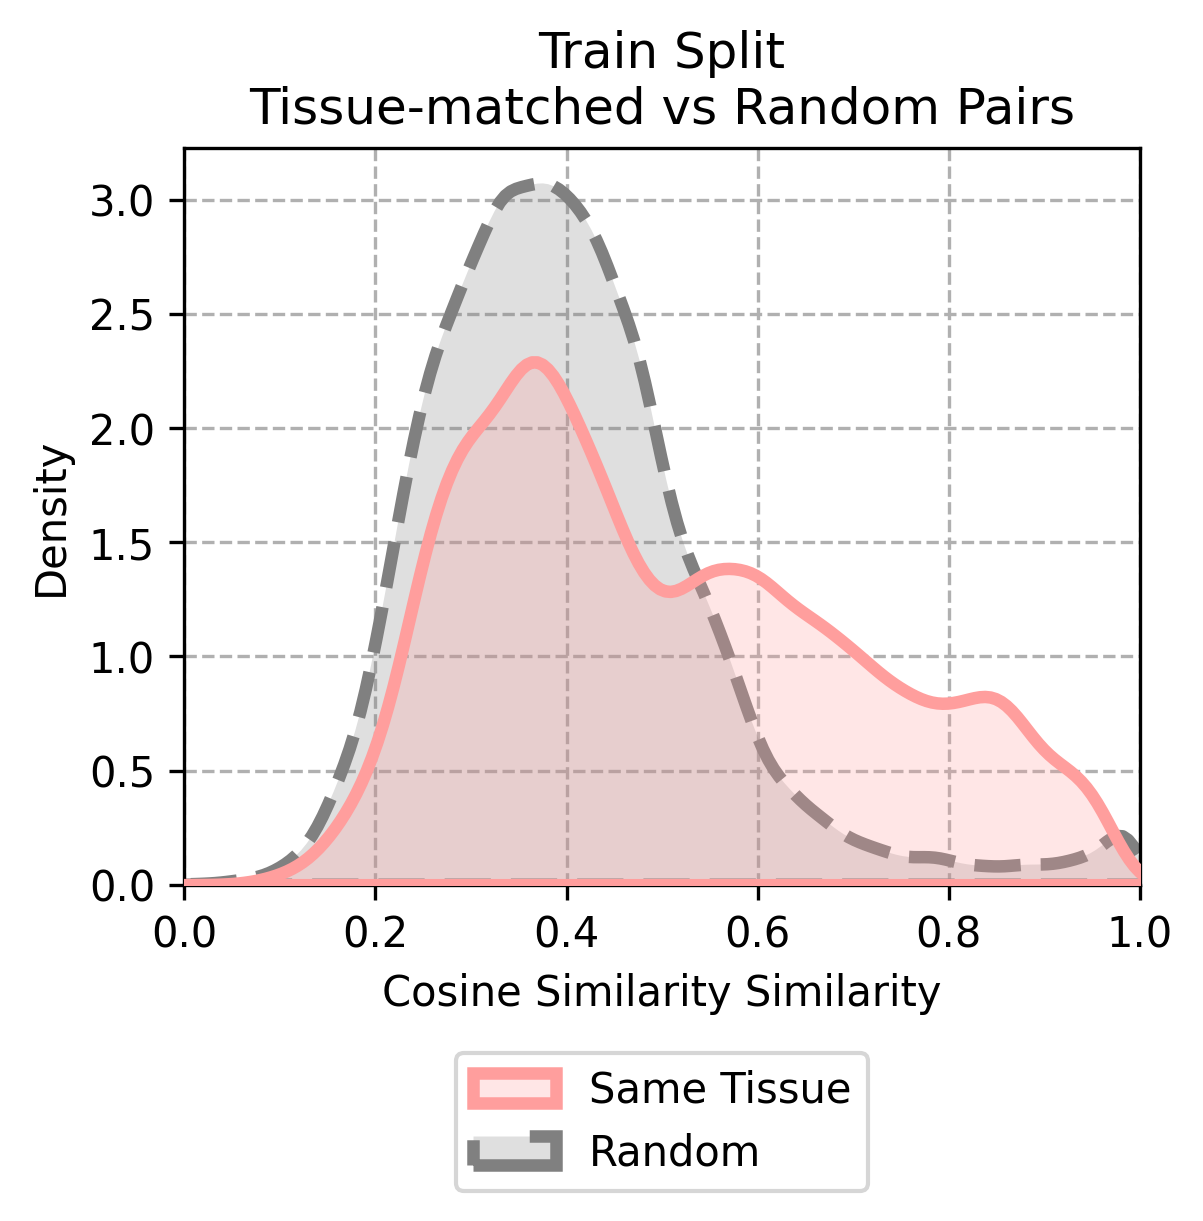

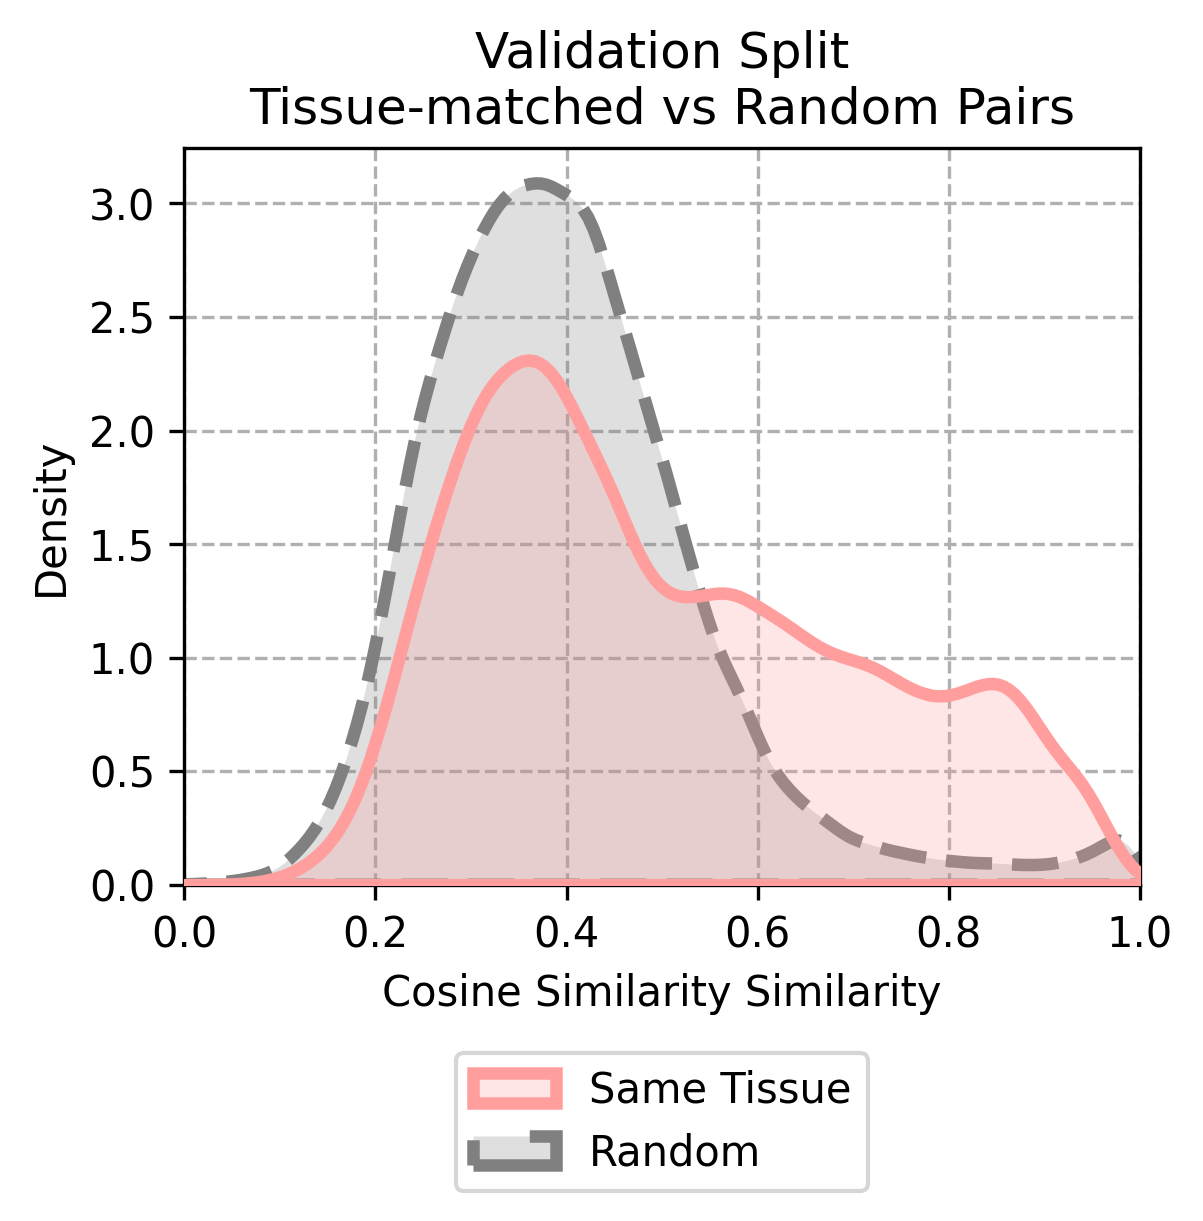

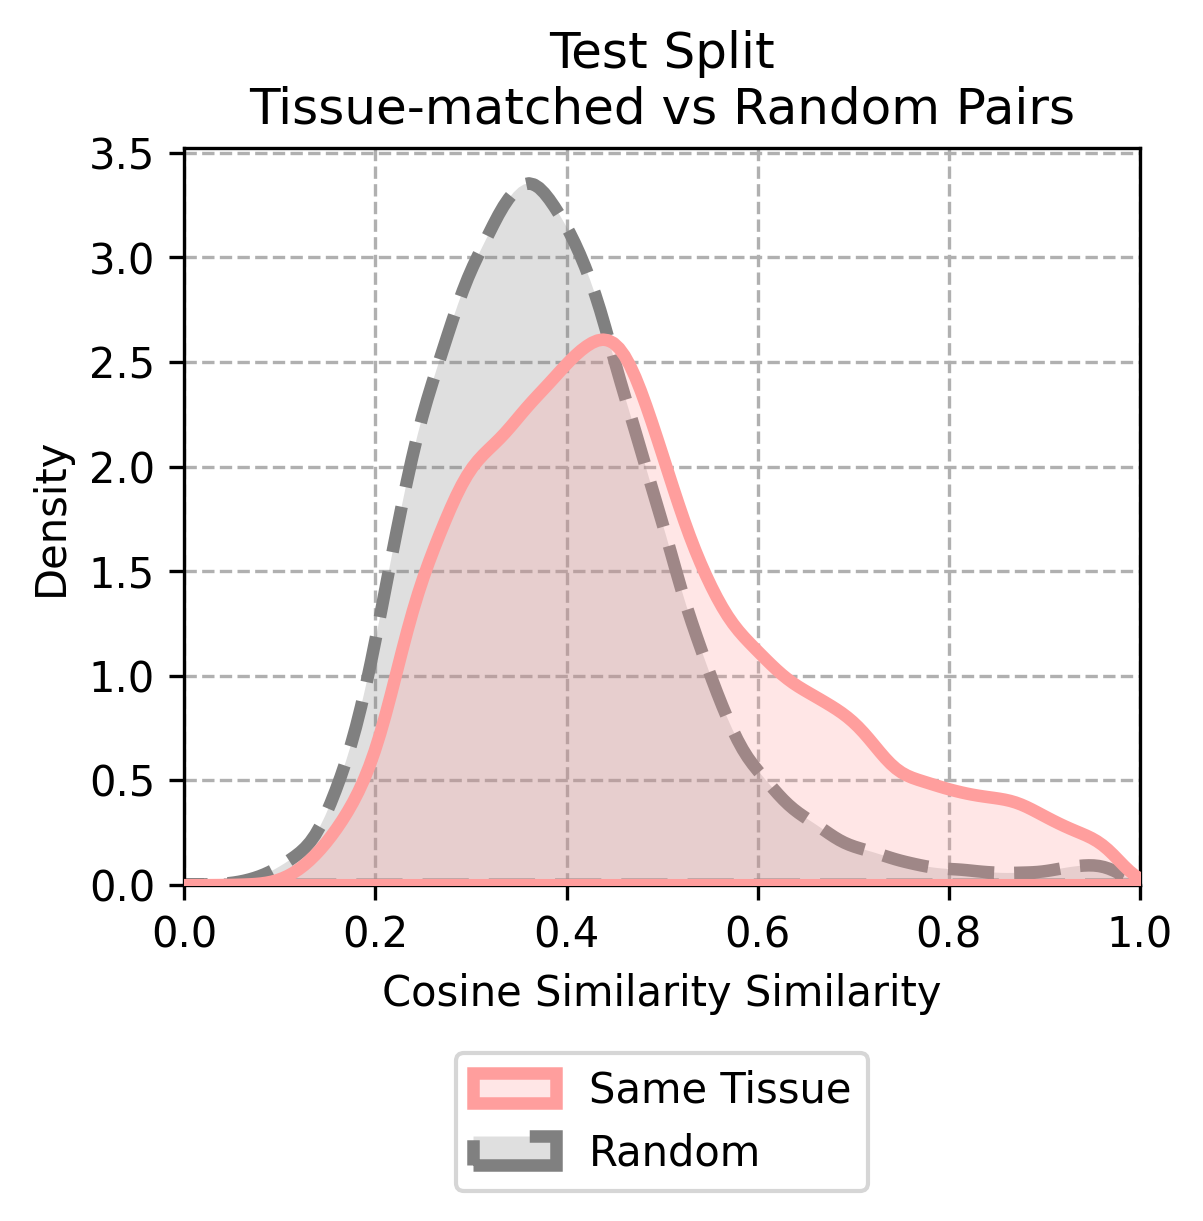

In [ ]:
# plot KDEs
tiss_scale = ["#ff9e9d", "grey"]
dpi = 300
_sample_size = 100000

vz.plot_kde([tr_s_tiss, tr_s_rand], 
            labels=["Same Tissue", "Random"],
            title="Train Split\nTissue-matched vs Random Pairs",
            colors=tiss_scale,
            # weights = [tr_w, np.array([1]*len(tr_s_rand))],
            weights=None,
            sample = _sample_size,   
            metric="Cosine Similarity",
            dpi=dpi)

vz.plot_kde([vl_s_tiss, vl_s_rand], 
            labels=["Same Tissue", "Random"],
            title="Validation Split\nTissue-matched vs Random Pairs",
            colors=tiss_scale,
            # weights = [vl_w, np.array([1]*len(vl_s_rand))],
            weights=None,
            sample = _sample_size,   
            metric="Cosine Similarity",
            dpi=dpi)

vz.plot_kde([ts_s_tiss, ts_s_rand], 
            labels=["Same Tissue", "Random"],
            title="Test Split\nTissue-matched vs Random Pairs",
            colors=tiss_scale,
            # weights = [ts_w, np.array([1]*len(ts_s_rand))],
            weights = None,
            sample = _sample_size,   
            metric="Cosine Similarity",
            dpi=dpi)


In [ ]:
df_all = pd.concat([df_train, df_valid, df_test], axis=0).reset_index(drop=True)

tiss_counts = df_all["tissue"].value_counts().to_dict()
n_total = sum(tiss_counts.values())
n_nan = tiss_counts.get("nan", 0)
n_non_nan = n_total - n_nan
blood_keys = [k for k in tiss_counts.keys() if "blood" in k.lower()]
n_blood = sum([tiss_counts[k] for k in blood_keys])
print(f"Nº of samples w/ non 'nan' tissue:\t{n_non_nan}\t{n_non_nan/n_total:.2f}%")
print(f"Nº of samples w/ 'blood' tissue:\t{n_blood}\t{n_blood/n_non_nan:.2f}%")

Nº of samples w/ non 'nan' tissue:	15921	0.62%
Nº of samples w/ 'blood' tissue:	4459	0.28%


In [ ]:

def plot_mean_std_by_tissue(similarity: np.ndarray,labels: np.ndarray, dpi:int=120, title:str="", metric:str="Cosine") -> None:
    # group by tissue
    tissues = np.unique(labels)
    
    mean_sim = np.zeros(len(tissues), dtype=float)
    std_sim  = np.zeros(len(tissues), dtype=float)
    counts   = np.zeros(len(tissues), dtype=int)

    for i, t in enumerate(tissues):
        # print(t, labels, [labels==t])
        vals = similarity[labels == t]
        mean_sim[i] = vals.mean() if len(vals) else np.nan
        std_sim[i]  = vals.std(ddof=1) if len(vals) > 1 else 0.0
        counts[i]   = len(vals)

    # ---- SORT BY SIZE (most -> least) ----
    order = np.argsort(counts)[::-1]  # descending
    tissues  = tissues[order]
    mean_sim = mean_sim[order]
    std_sim  = std_sim[order]
    counts   = counts[order]

    # plot (two y-axes)
    x = np.arange(len(tissues))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 4), dpi=dpi)

    # y-axis 1: mean similarity with whiskers
    bars1 = ax1.bar(
        x - width/2,
        mean_sim,
        width,
        yerr=std_sim,
        # capsize=4,
        color="#ff9e9d",
        error_kw={
        "elinewidth": 1,     # thickness of whisker line
        "ecolor": "black",     # color of whiskers
        "capthick": 1       # thickness of caps
            },
        label=f"{metric} similarity (±SD)"
    )
    ax1.set_ylabel(f"{metric} similarity")

    # y-axis 2: counts
    ax2 = ax1.twinx()
    bars2 = ax2.bar(
        x + width/2,
        counts,
        width,
        color="grey",
        label="Nº of Comparisons"
    )
    ax2.set_ylabel("Nº of Comparisons")

    # x-axis
    ax1.set_xticks(x)
    ax1.set_xticklabels(tissues, rotation=90, ha="right")
    ax1.set_title(title)

    # reduce side margins
    ax1.set_xlim(-0.5, len(tissues) - 0.5)


    # Control grid lines independently for ax1 and ax2

    # ---- GRID FOR ax1 (mean similarity) ----
    ax1.grid(
        True,
        which="major",
        axis="y",          # grid only on y-axis
        linestyle="--",
        linewidth=0.8,
        alpha=0.6,
    )

    # Turn OFF x-grid on ax1
    ax1.grid(False, axis="x")

    # Make sure ax2 grid is behind bars
    ax2.set_axisbelow(True)
    ax2.grid(False)

    # show main plot WITHOUT legend
    plt.tight_layout()
    plt.show()

    # ---- Separate legend-only figure ----
    fig_leg = plt.figure(figsize=(2, 1.2), dpi=dpi)
    fig_leg.legend(
        handles=[bars1[0], bars2[0]],
        labels=[f"{metric} Similarity (x̄±SD)", "Nº Comparisons"],
        loc="center",
        ncol=2,
        frameon=True
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()



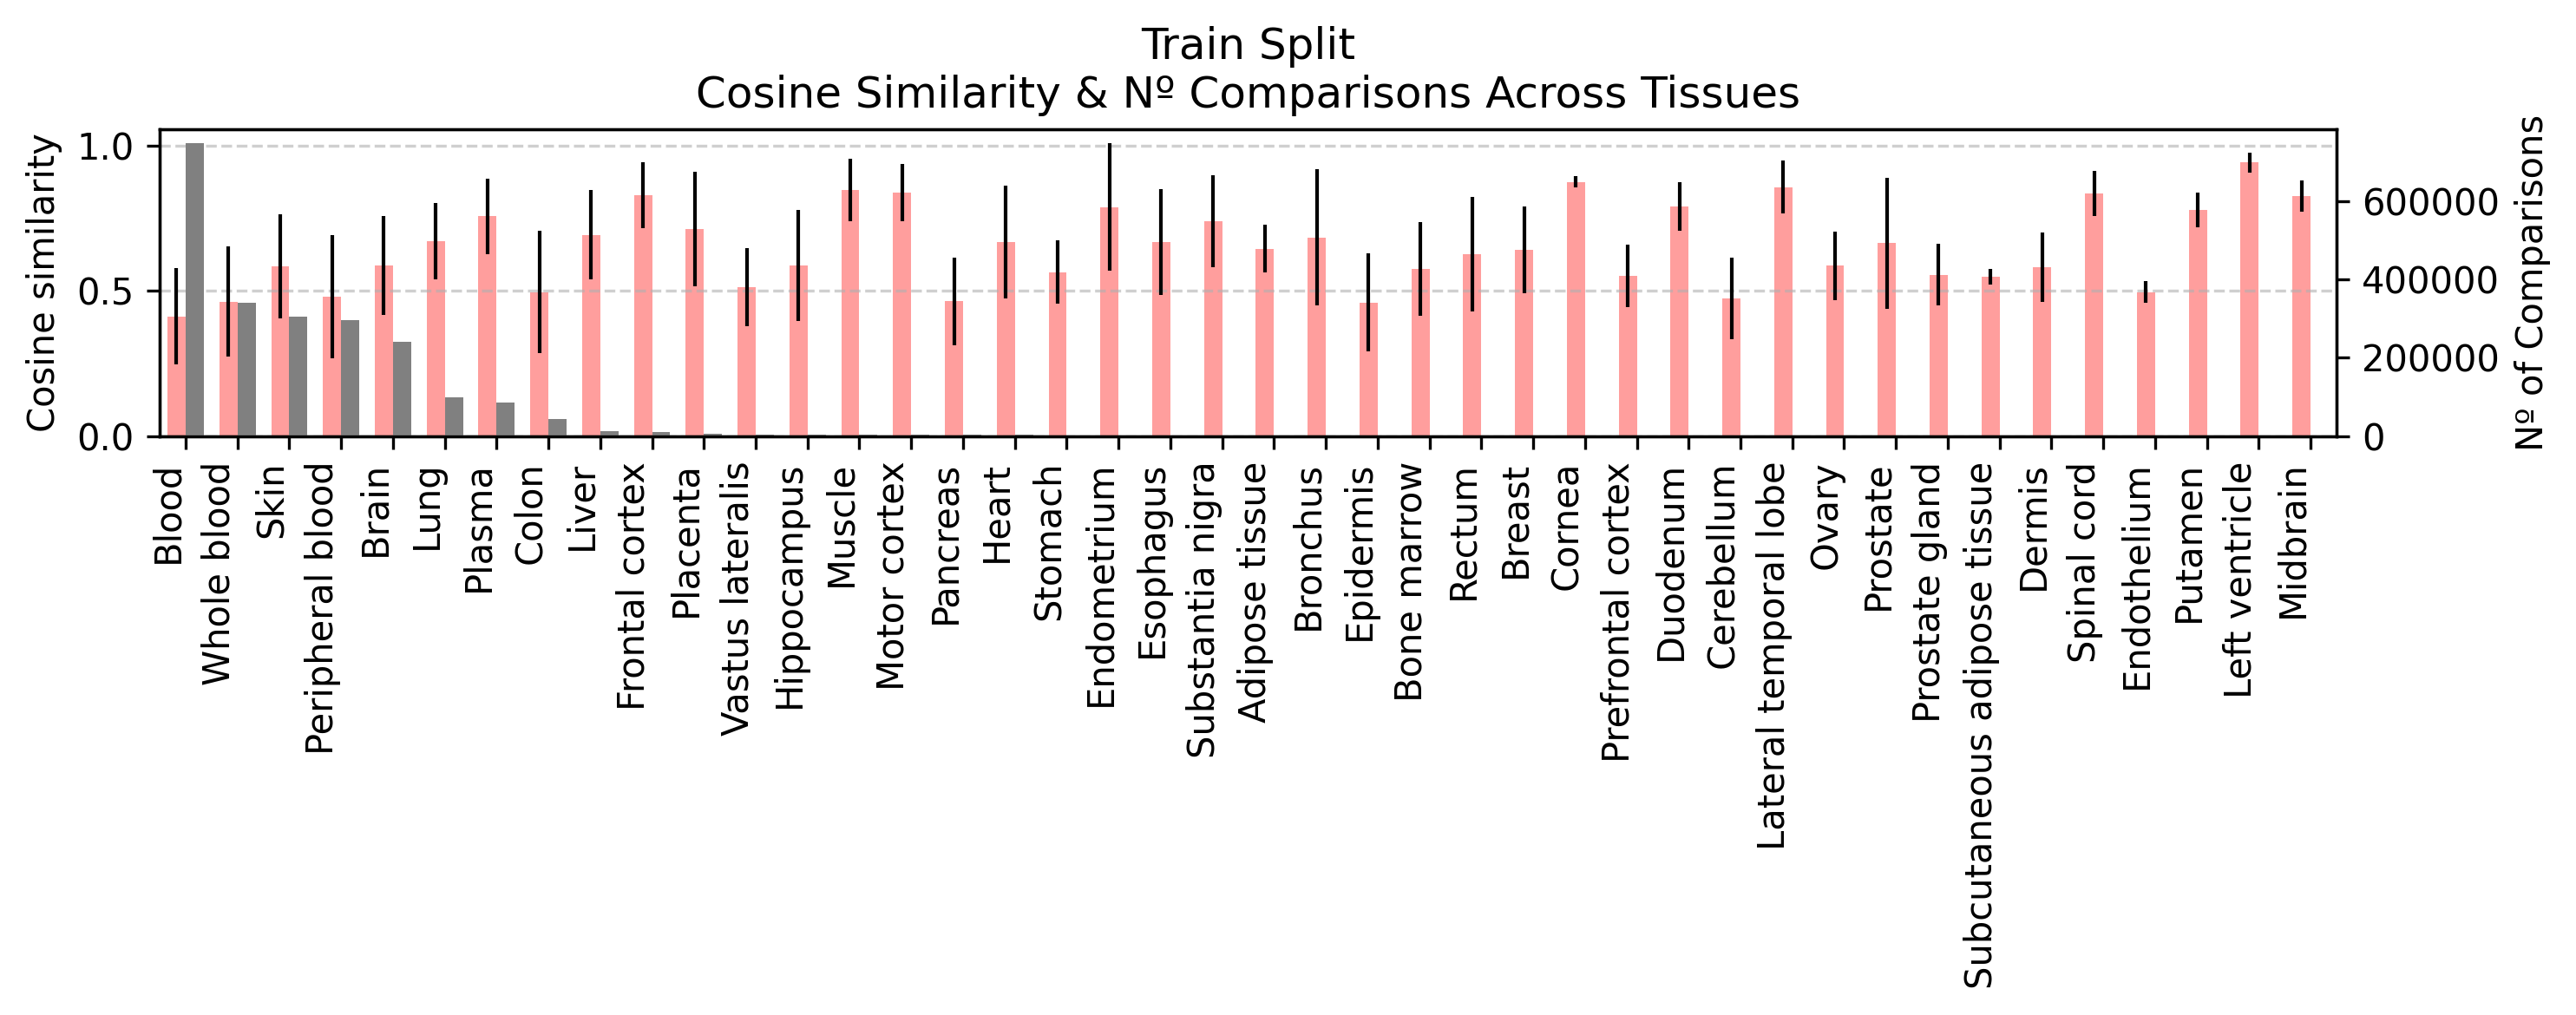

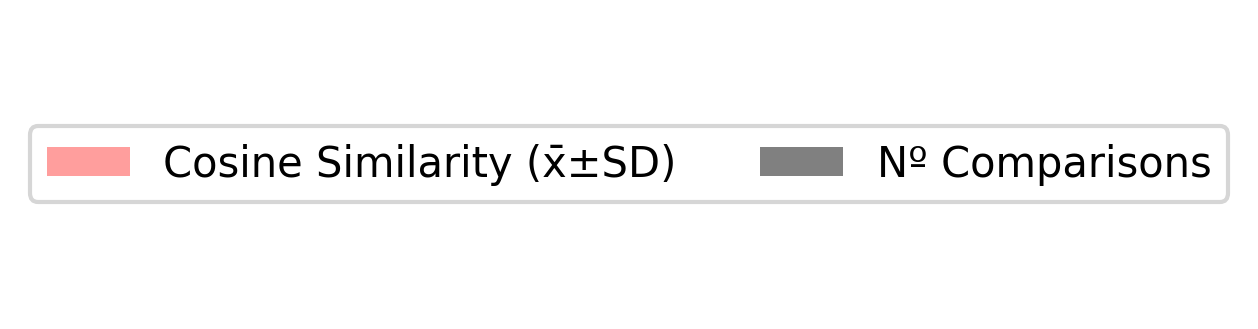

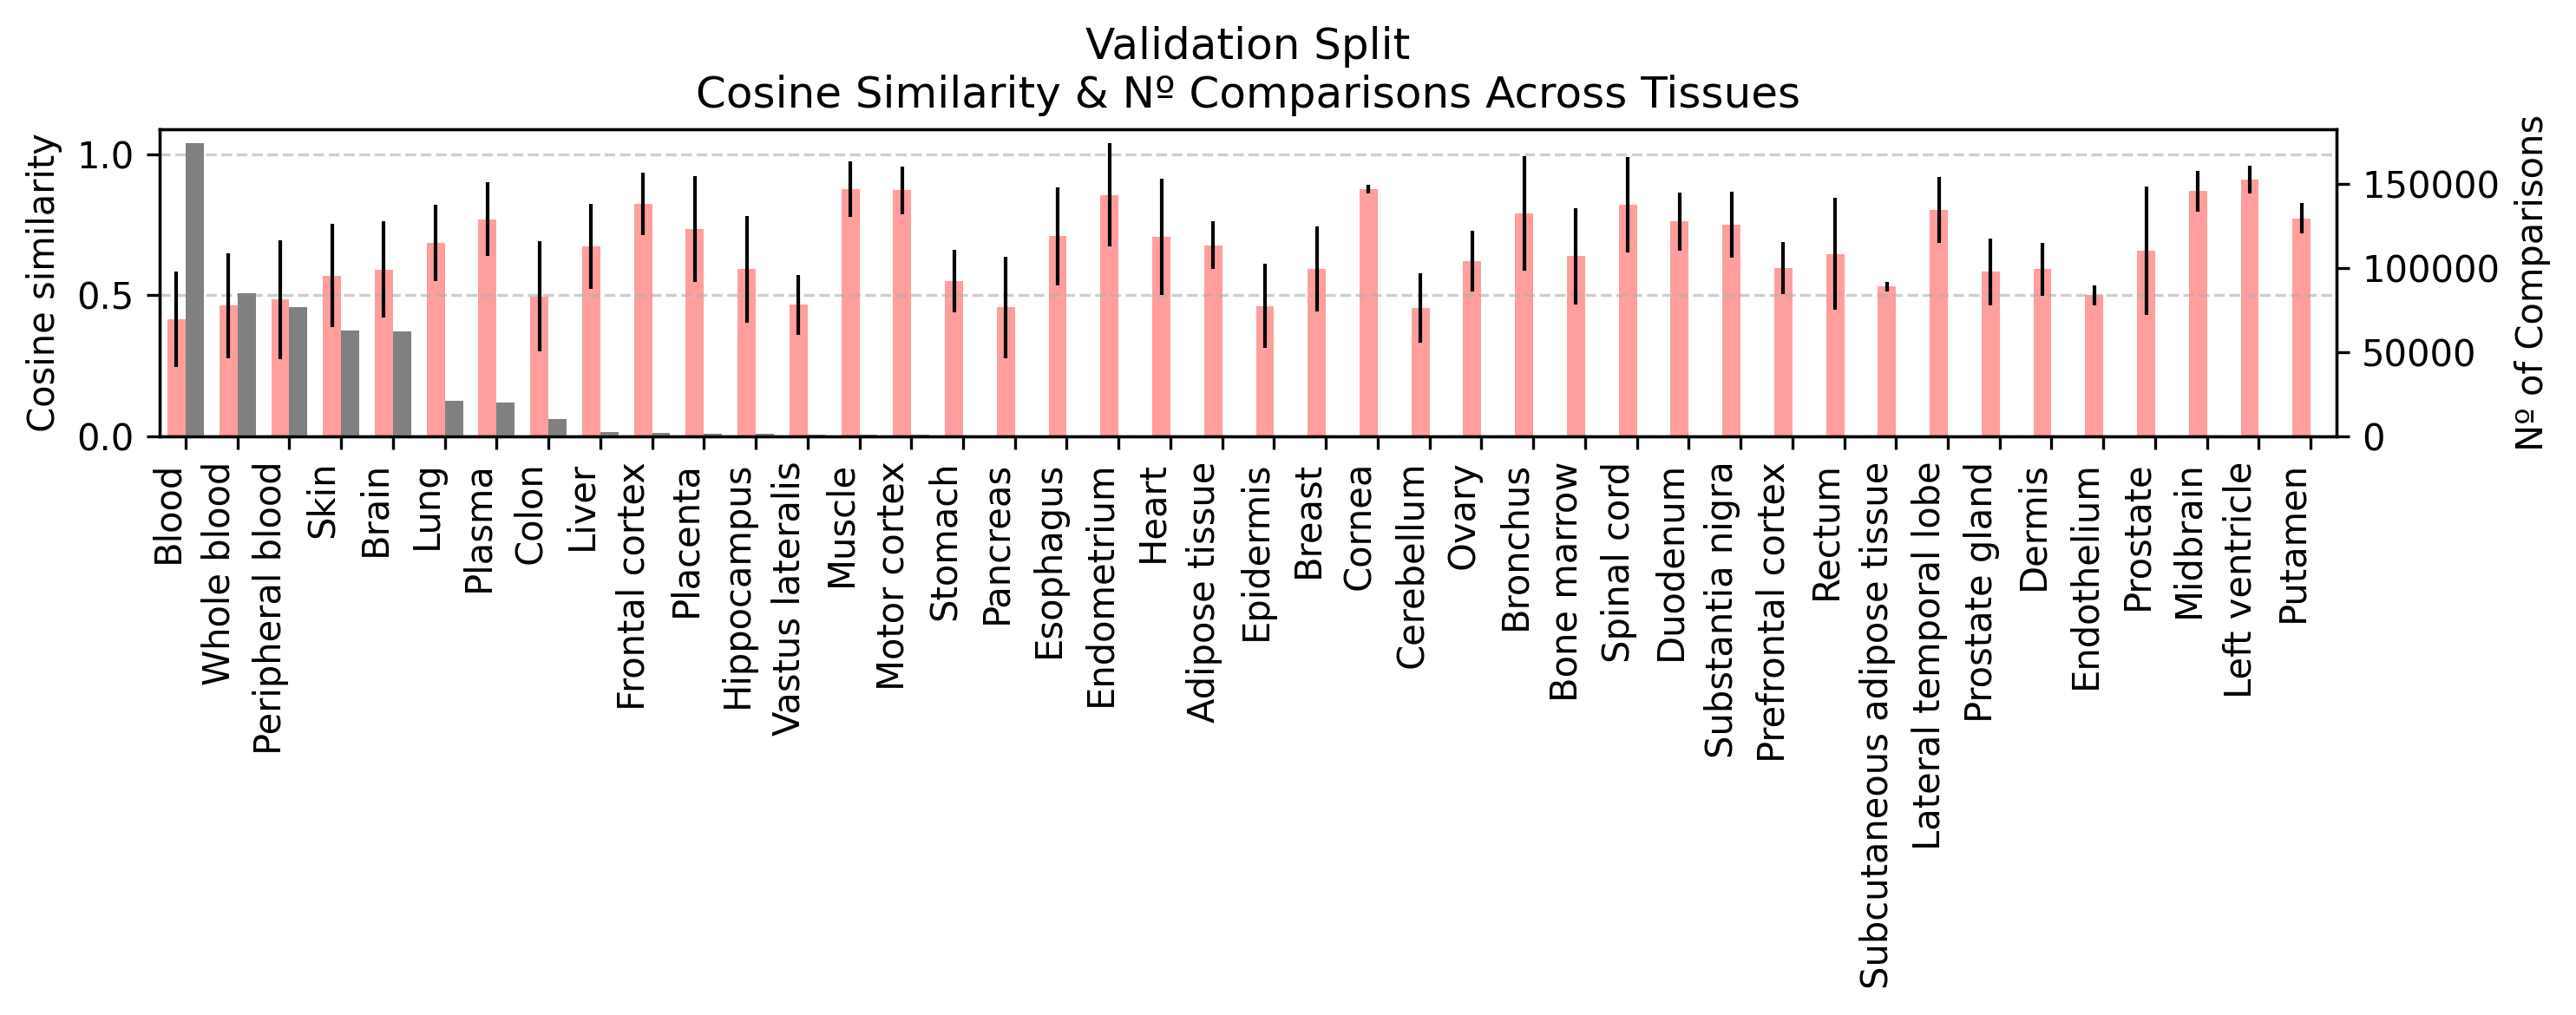

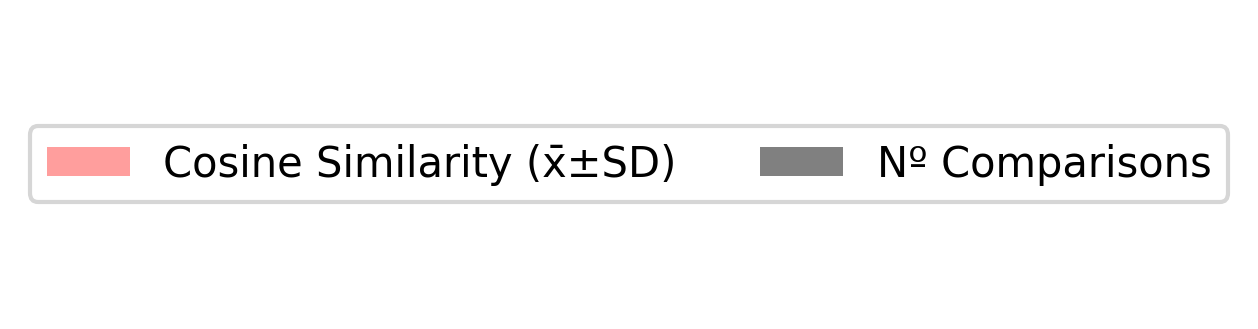

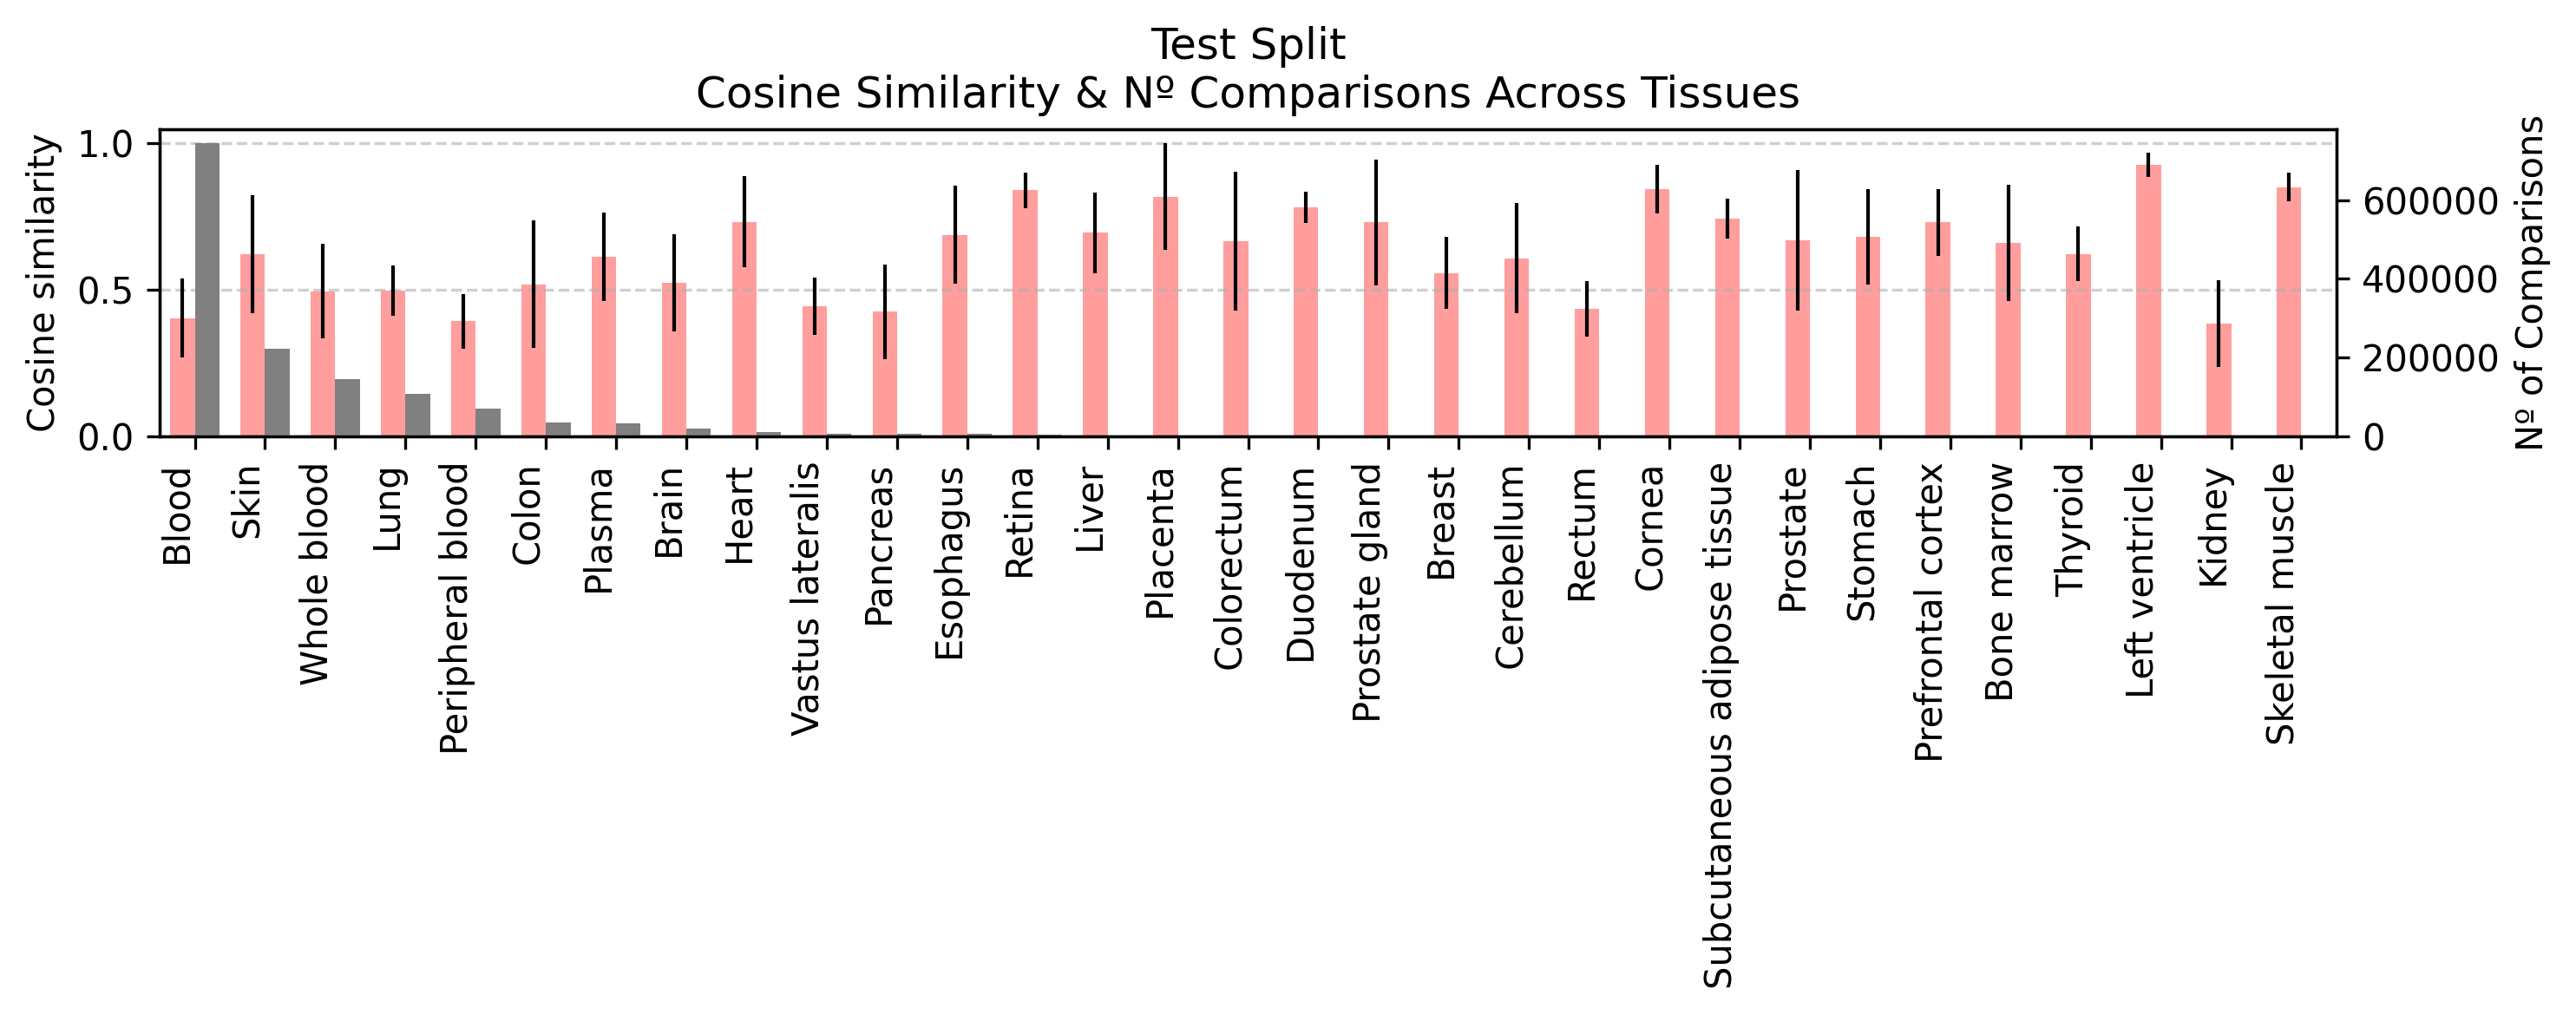

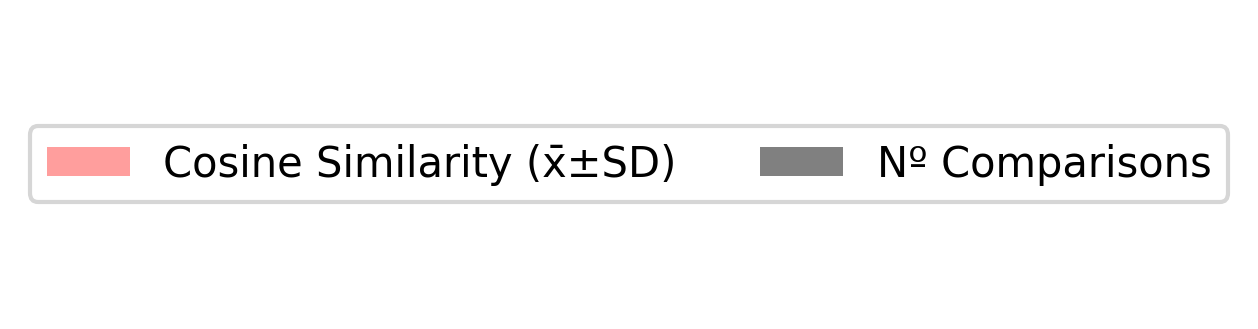

In [ ]:
# plot similarity stratified by tissue
plot_mean_std_by_tissue(tr_s_tiss, np.array(tr_l), title="Train Split\nCosine Similarity & Nº Comparisons Across Tissues", dpi=dpi)
plot_mean_std_by_tissue(vl_s_tiss, np.array(vl_l), title="Validation Split\nCosine Similarity & Nº Comparisons Across Tissues", dpi=dpi)
plot_mean_std_by_tissue(ts_s_tiss, np.array(ts_l), title="Test Split\nCosine Similarity & Nº Comparisons Across Tissues", dpi=dpi)

# Junkyard

In [ ]:
def get_tiss_idxs_pairs(uniq_tiss:List[Tuple], tiss_ids:List, datasets:List=None, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    # remove nan tissue if present
    uniq_tiss.remove("nan") if "nan" in uniq_tiss else None

    universe_pairs = list()
    l_weights = list()  # label weights
    for tiss_i in tqdm(uniq_tiss):
        
        # retrieve tissue idxs pairs
        idx1 = np.where(tiss_ids == tiss_i)[0]

        # compute idx combinations
        idx_pairs = list(itertools.combinations(idx1, 2))

        # if ONLY take into account tisseases DIFFERENT datasets
        #! NOTE - BEST WAY TO REMOVE SAME DATASETS - SHOULD BE APPLIED ALWAYS
        if datasets is not None:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([f"{tiss_i}"] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs
    
def get_tiss_idxs_pairs_split(uniq_tiss:List, do_ids_1:List, do_ids_2:List, datasets_1:List=None, datasets_2:List=None, do_diff_dt:bool=True, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    # remove nan tissue if present
    uniq_tiss.remove("nan") if "nan" in uniq_tiss else None

    # make sure do_ids_1 & do_ids_2 are arrays
    do_ids_1 = np.array(do_ids_1)
    do_ids_2 = np.array(do_ids_2)

    universe_pairs = list()
    l_weights = list()  # label weights

    for tiss_i in tqdm(uniq_tiss):
        
        idx1_1 = np.where(do_ids_1 == tiss_i)[0]    # idxs disease a in split 1
        idx1_2 = np.where(do_ids_2 == tiss_i)[0]    # idxs disease b in split 2

        # compute idx combinations disease a 
        idx_pairs = list(itertools.product(idx1_1, idx1_2))

        # if ONLY take into account diseases DIFFERENT datasets
        #! NOTE - BEST WAY TO REMOVE SAME DATASETS - SHOULD BE APPLIED ALWAYS
        if do_diff_dt:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets_1[p[0]] != datasets_2[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([tiss_i] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs
    

In [ ]:
def get_dis_tiss_idxs(pairs:List[Tuple], do_ids:List, tissue_ids, datasets:List=None, same_tiss:bool=False, diff_tiss:bool=True, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    universe_pairs = list()
    l_weights = list()  # label weights
    for doid_a, doid_b in tqdm(pairs):
        
        # retrieve disease idxs pairs
        idx1 = np.where(do_ids == doid_a)[0]
        idx2 = np.where(do_ids == doid_b)[0]

        # compute idx combinations
        idx_pairs = list(itertools.product(idx1, idx2))


        # if ONLY take into account diseases DIFFERENT datasets
        #! NOTE - BEST WAY TO REMOVE SAME DATASETS - SHOULD BE APPLIED ALWAYS
        if datasets is not None:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        # we do not want 'nan' in tissue comparisons!
        idx_pairs = [p for p in idx_pairs if tissue_ids[p[0]] != "nan" and tissue_ids[p[1]] != "nan"]

        if same_tiss:
            # filter by SAME tissue
            idx_pairs = [p for p in idx_pairs if tissue_ids[p[0]] == tissue_ids[p[1]]]
        
        if diff_tiss:
            # filter by DIFFERENT tissue
            idx_pairs = [p for p in idx_pairs if tissue_ids[p[0]] != tissue_ids[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([f"{doid_a} - {doid_b}"] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:

        return universe_pairs


In [ ]:
def get_dis_dts_idxs(pairs:List[Tuple], do_ids:List, dataset_ids, same_dts:bool=False, diff_dts:bool=True, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    universe_pairs = list()
    l_weights = list()  # label weights
    for doid_a, doid_b in tqdm(pairs):
        
        # retrieve disease idxs pairs
        idx1 = np.where(do_ids == doid_a)[0]
        idx2 = np.where(do_ids == doid_b)[0]

        # compute idx combinations
        idx_pairs = list(itertools.product(idx1, idx2))


        # if ONLY take into account diseases DIFFERENT datasets
        #! NOTE - BEST WAY TO REMOVE SAME DATASETS - SHOULD BE APPLIED ALWAYS
        # if datasets is not None:
        #     # filter by datasets
        #     idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        # we do not want 'nan' in tissue comparisons!
        idx_pairs = [p for p in idx_pairs if dataset_ids[p[0]] != "nan" and dataset_ids[p[1]] != "nan"]

        if same_dts:
            # filter by SAME tissue
            idx_pairs = [p for p in idx_pairs if dataset_ids[p[0]] == dataset_ids[p[1]]]
        
        if diff_dts:
            # filter by DIFFERENT tissue
            idx_pairs = [p for p in idx_pairs if dataset_ids[p[0]] != dataset_ids[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([f"{doid_a} - {doid_b}"] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:

        return universe_pairs


lin_val = 0.6

rel_pairs = do_df_ic_query.query(f"lin >={lin_val}")["pair_sorted"].to_list()
unrel_pairs = do_df_negative_ic["pair_sorted"].to_list()

idx_diff_dts, l_diff_dts = get_dis_dts_idxs(rel_pairs,
                   df_train["doid_id"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_dts=False,
                   diff_dts=True,
                   return_weights=True)

idx_same_dts, l_same_dts = get_dis_dts_idxs(unrel_pairs,
                   df_train["doid_id"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_dts=True,
                   diff_dts=False,
                   return_weights=True)

idx_same_dts_2, l_same_dts_2 = get_dis_dts_idxs([(d,d) for d in df_train["doid_id"].unique() if d != "Control"],
                   df_train["doid_id"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_dts=True,
                   diff_dts=False,
                   return_weights=True)

idx_same_dts_3, l_same_dts_3 = get_dis_dts_idxs(rel_pairs,
                   df_train["doid_id"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_dts=True,
                   diff_dts=False,
                   return_weights=True)

unrelated_pairs = do_df_negative_ic["pair_sorted"].to_list()
tr_idx_unr =  vz.get_doid_idxs_pairs(unrelated_pairs, df_train["do_id"].to_numpy(), return_weights=False)


100%|██████████| 6586/6586 [00:03<00:00, 1786.96it/s]


In [ ]:
idx_same_dts_2, l_same_dts_2 = get_dis_dts_idxs([(d,d) for d in df_train["doid_id"].unique() if d != "Control"],
                   df_train["doid_id"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_dts=True,
                   diff_dts=False,
                   return_weights=True)

100%|██████████| 123/123 [00:01<00:00, 100.09it/s]


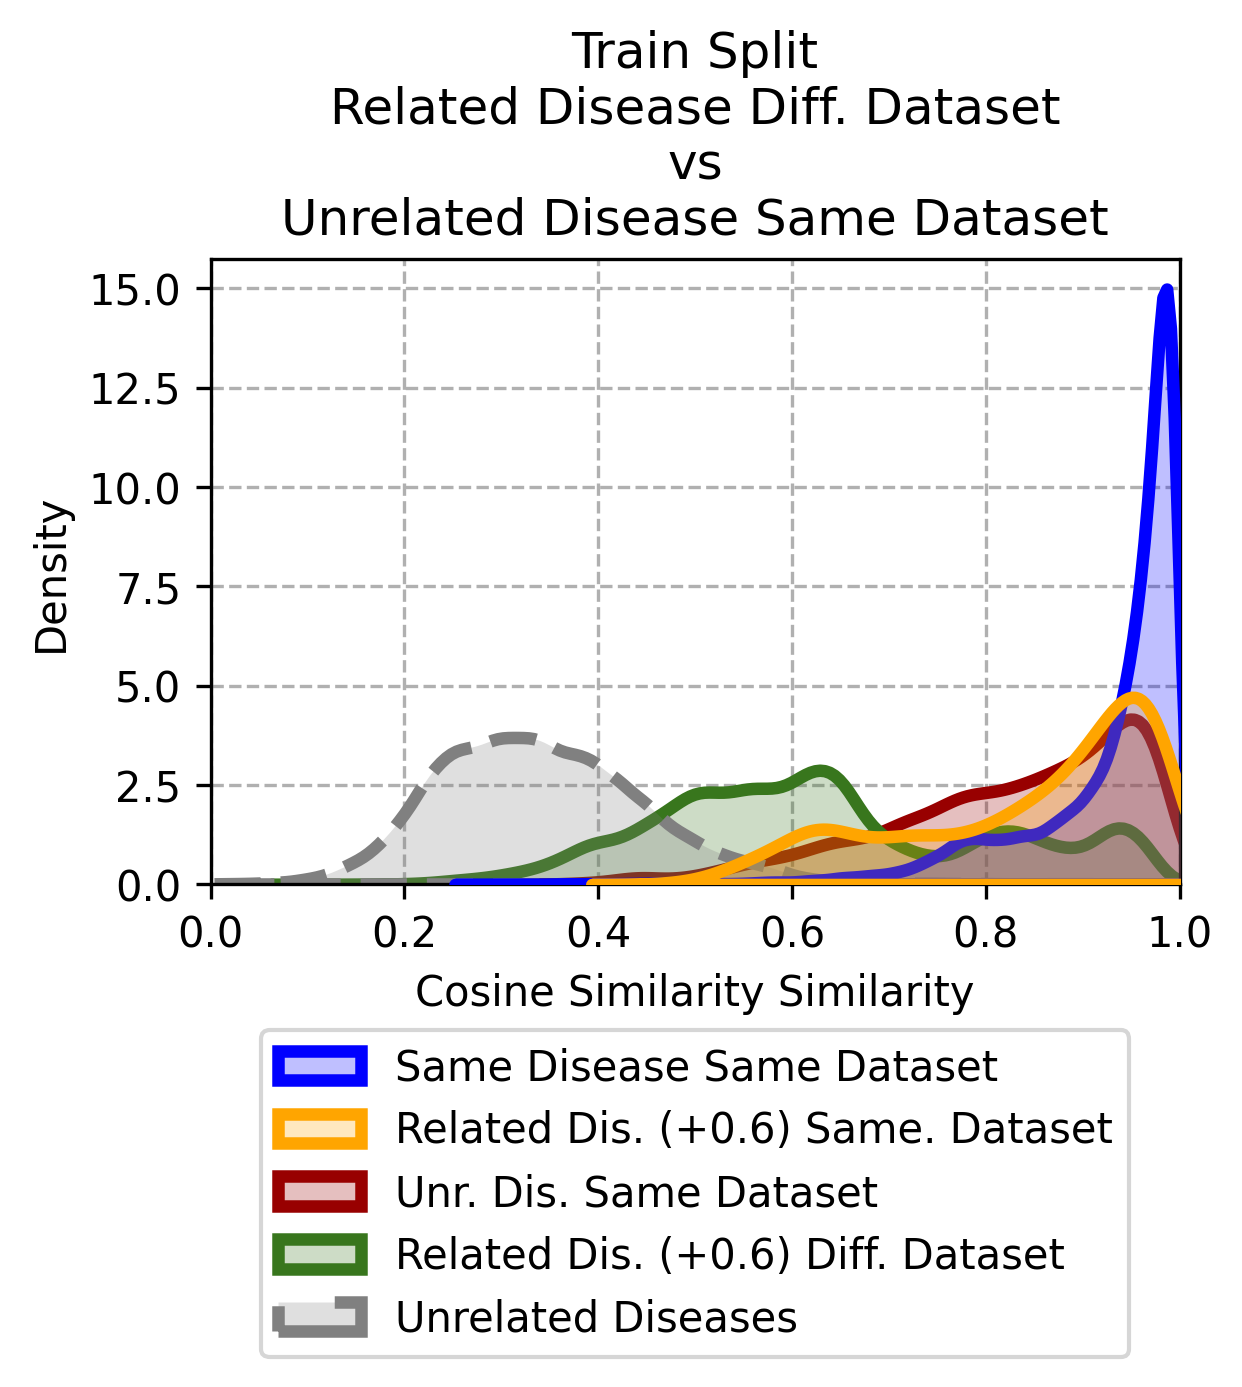

In [ ]:
tr_s_diff_dts = c_matrix_train[idx_diff_dts[:,0], idx_diff_dts[:,1]]
tr_s_same_dts = c_matrix_train[idx_same_dts[:,0], idx_same_dts[:,1]]
tr_s_same_dts_2 = c_matrix_train[idx_same_dts_2[:,0], idx_same_dts_2[:,1]]
tr_s_same_dts_3 = c_matrix_train[idx_same_dts_3[:,0], idx_same_dts_3[:,1]]
tr_s_unr = c_matrix_train[tr_idx_unr[:,0], tr_idx_unr[:,1]]

dts_scale = [ "blue","orange","#980000","#38761d","grey"]
dpi = 300
_sample_size = 100000

vz.plot_kde([tr_s_same_dts_2,tr_s_same_dts_3, tr_s_same_dts, tr_s_diff_dts, tr_s_unr], 
            labels=["Same Disease Same Dataset", f"Related Dis. (+{lin_val}) Same. Dataset","Unr. Dis. Same Dataset",f"Related Dis. (+{lin_val}) Diff. Dataset","Unrelated Diseases"],
            title="Train Split\nRelated Disease Diff. Dataset\nvs\nUnrelated Disease Same Dataset",
            colors=dts_scale,
            weights = [tr_w, np.array([1]*len(tr_s_rand))],
            weights=None,
            sample = _sample_size,   
            metric="Cosine Similarity",
            dpi=dpi)


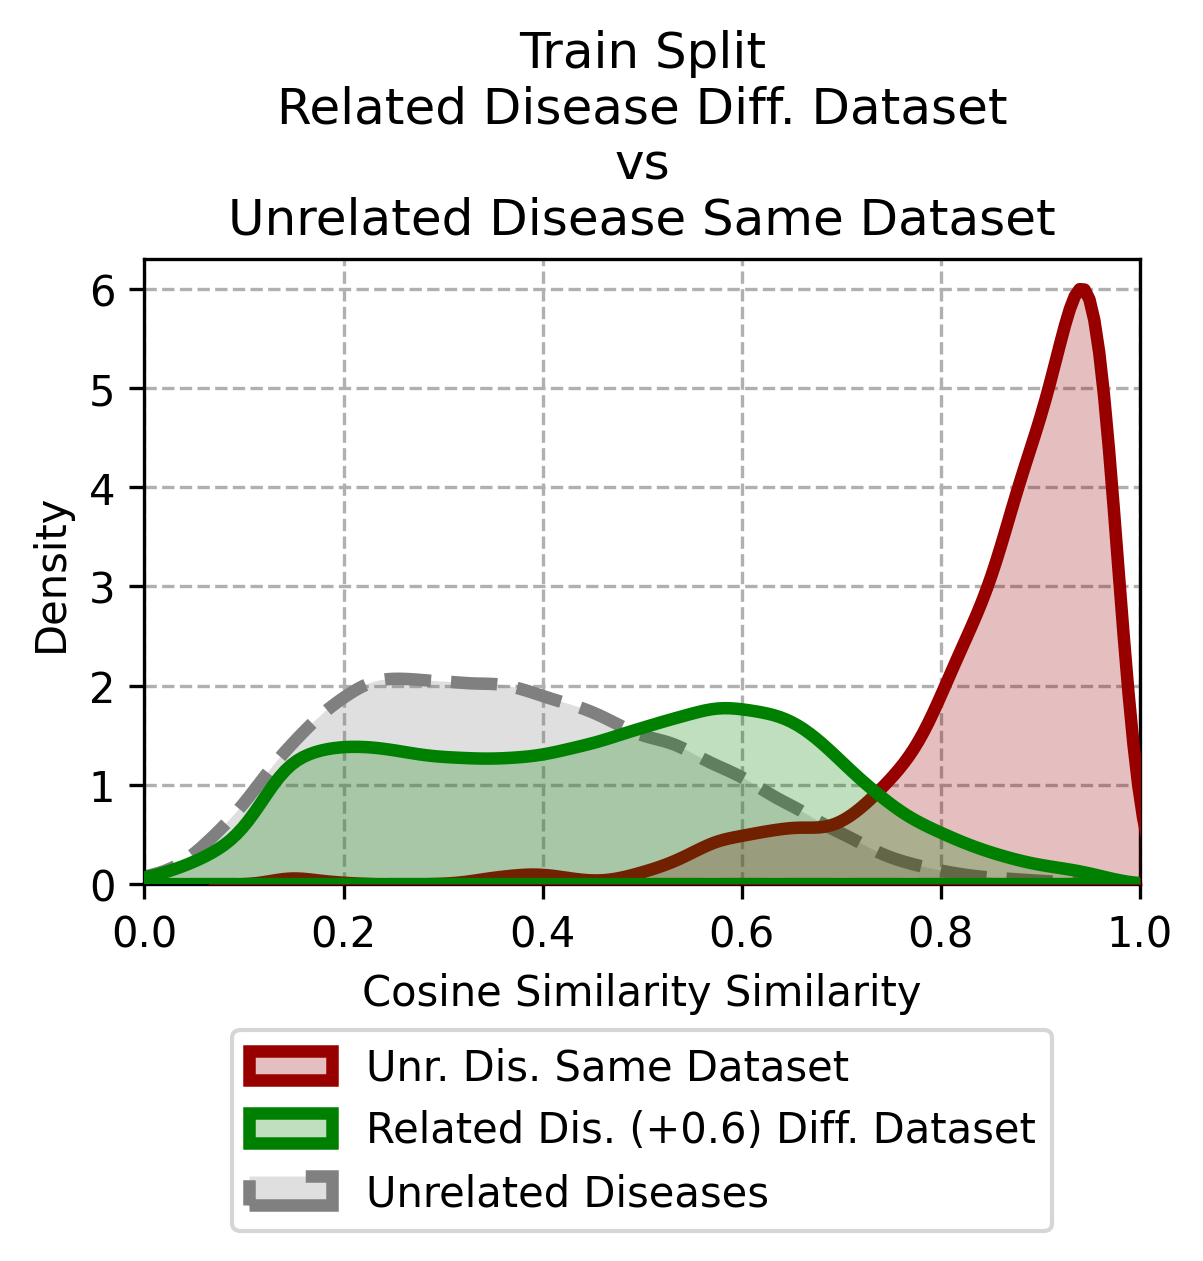

In [ ]:
tr_s_diff_dts = c_matrix_train[idx_diff_dts[:,0], idx_diff_dts[:,1]]
tr_s_same_dts = c_matrix_train[idx_same_dts[:,0], idx_same_dts[:,1]]
tr_s_unr = c_matrix_train[tr_idx_unr[:,0], tr_idx_unr[:,1]]

dts_scale = [ "#980000","#38761d","grey"]
dts_scale = [ "#980000","green","grey"]
dpi = 300
_sample_size = 100000

vz.plot_kde([tr_s_same_dts, tr_s_diff_dts, tr_s_unr], 
            labels=["Unr. Dis. Same Dataset",f"Related Dis. (+{lin_val}) Diff. Dataset","Unrelated Diseases"],
            title="Train Split\nRelated Disease Diff. Dataset\nvs\nUnrelated Disease Same Dataset",
            colors=dts_scale,
            # weights = [tr_w, np.array([1]*len(tr_s_rand))],
            weights=None,
            sample = _sample_size,   
            metric="Cosine Similarity",
            dpi=dpi)


In [ ]:
plt.scatter()

TypeError: scatter() missing 2 required positional arguments: 'x' and 'y'

In [ ]:
lin_val = 0.8

rel_pairs = do_df_ic_query.query(f"lin >={lin_val}")["pair_sorted"].to_list()
unrel_pairs = do_df_negative_ic["pair_sorted"].to_list()

idx_diff_tiss, l_diff_tiss = get_dis_tiss_idxs(rel_pairs,
                   df_train["doid_id"].to_numpy(),
                   df_train["tissue"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_tiss=False,
                   diff_tiss=True,
                   return_weights=True)

idx_same_tiss, l_same_tiss = get_dis_tiss_idxs(unrel_pairs,
                   df_train["doid_id"].to_numpy(),
                   df_train["tissue"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   same_tiss=True,
                   diff_tiss=False,
                   return_weights=True)


100%|██████████| 6586/6586 [00:18<00:00, 360.45it/s] 


In [ ]:
unrelated_pairs = do_df_negative_ic["pair_sorted"].to_list()
tr_idx_unr =  vz.get_doid_idxs_pairs(unrelated_pairs, df_train["do_id"].to_numpy(), return_weights=False)


100%|██████████| 6586/6586 [00:03<00:00, 1837.17it/s]


In [ ]:
tr_s_diff_tiss = c_matrix_train[idx_diff_tiss[:,0], idx_diff_tiss[:,1]]
tr_s_same_tiss = c_matrix_train[idx_same_tiss[:,0], idx_same_tiss[:,1]]
tr_s_unr = c_matrix_train[tr_idx_unr[:,0], tr_idx_unr[:,1]]

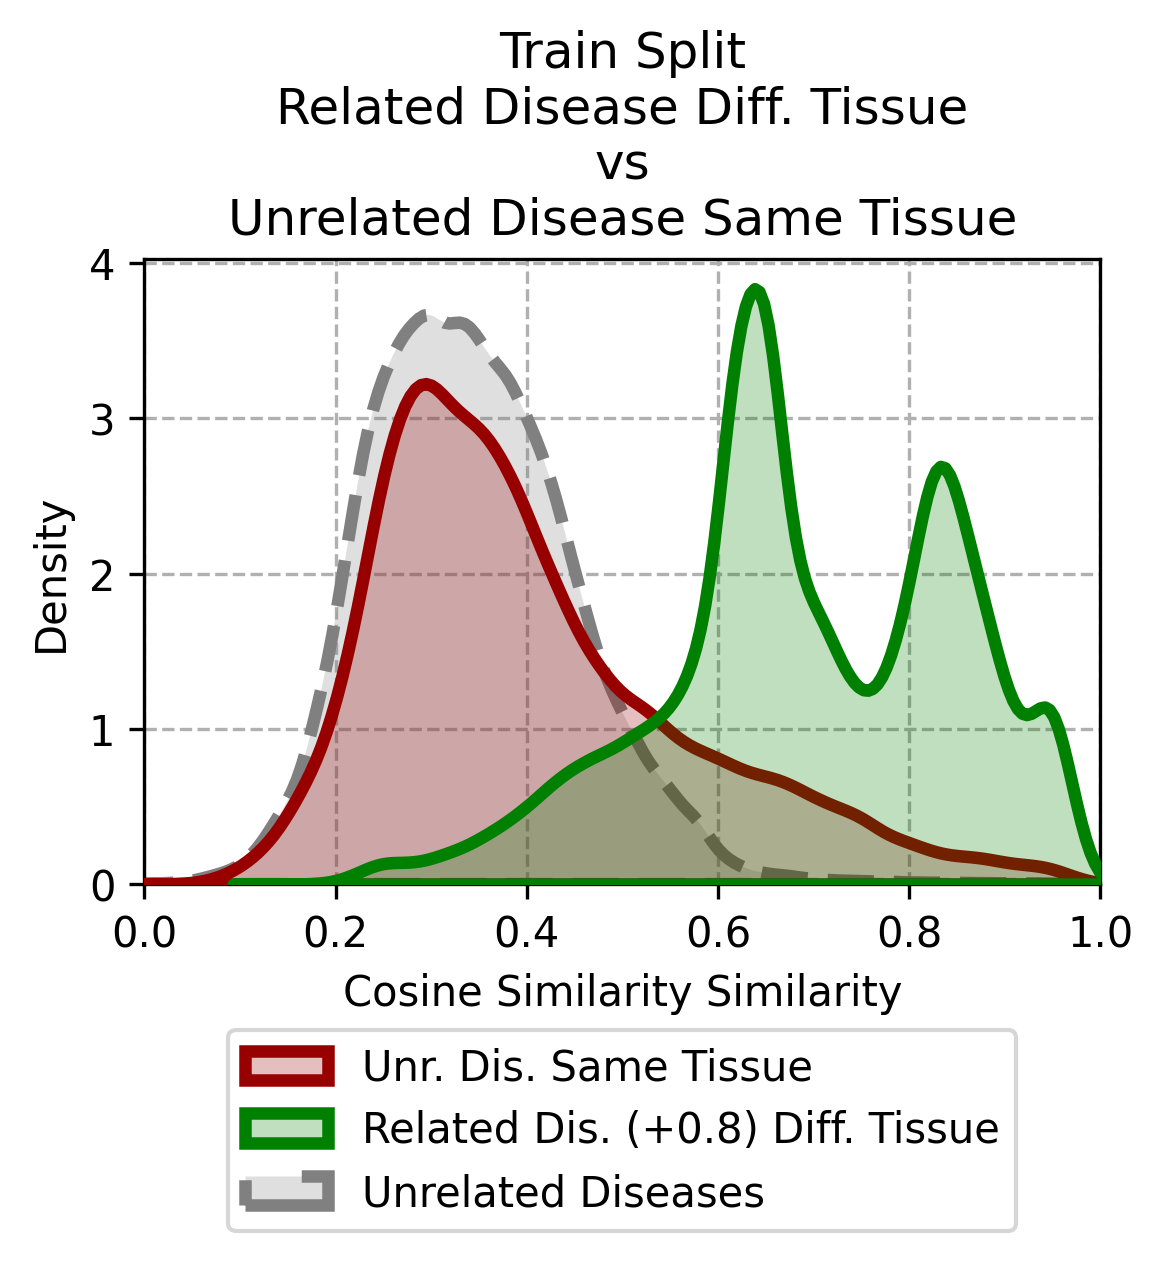

In [ ]:
tiss_scale = [ "#980000","#38761d","grey"]
tiss_scale = [ "#980000","green","grey"]
dpi = 300
_sample_size = 100000

vz.plot_kde([tr_s_same_tiss, tr_s_diff_tiss, tr_s_unr], 
            labels=["Unr. Dis. Same Tissue",f"Related Dis. (+{lin_val}) Diff. Tissue","Unrelated Diseases"],
            title="Train Split\nRelated Disease Diff. Tissue\nvs\nUnrelated Disease Same Tissue",
            colors=tiss_scale,
             # weights = [tr_w, np.array([1]*len(tr_s_rand))],
            weights=None,
            sample = _sample_size,   
            metric="Cosine Similarity",
            dpi=dpi)


In [ ]:
do_df_ic_query[do_df_ic_query["lin"]>0.8]

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
5166643,DOID:0050700,DOID:11984,"[DOID:0050700, DOID:11984]",6.339409,0.873543,1.835435,DOID:0050700,2
5166949,DOID:0050700,DOID:12930,"[DOID:0050700, DOID:12930]",6.339409,0.917352,1.142287,DOID:0050700,2
10590549,DOID:0060161,DOID:12377,"[DOID:0060161, DOID:12377]",7.546235,0.812572,3.481240,DOID:12377,1
27643717,DOID:0080199,DOID:1993,"[DOID:0080199, DOID:1993]",8.382483,0.818070,3.728337,DOID:9256,2
35132759,DOID:0081087,DOID:9119,"[DOID:0081087, DOID:9119]",8.186272,0.855691,2.761160,DOID:9119,1
55453996,DOID:10286,DOID:2526,"[DOID:10286, DOID:2526]",9.666499,0.964434,0.712950,DOID:10286,1
55735314,DOID:1040,DOID:9952,"[DOID:1040, DOID:9952]",7.847340,0.859016,2.575844,DOID:1037,3
56053641,DOID:10591,DOID:10763,"[DOID:10591, DOID:10763]",8.328994,0.916391,1.519826,DOID:10763,1
56117375,DOID:10608,DOID:8577,"[DOID:10608, DOID:8577]",8.932529,0.826811,3.742124,DOID:0060031,2
57005403,DOID:1107,DOID:3748,"[DOID:1107, DOID:3748]",9.928863,0.941149,1.241713,DOID:1107,1


In [ ]:
for p in tr_idx[:100]:
    a = df_train["dataset"].to_numpy()[p[0]]
    b = df_train["dataset"].to_numpy()[p[1]]

    a_2 = df_train["tissue"].to_numpy()[p[0]]
    b_2 = df_train["tissue"].to_numpy()[p[1]]

    a_3 = df_train["disease"].to_numpy()[p[0]]
    b_3 = df_train["disease"].to_numpy()[p[1]]
    
    print(a, b, "||", a_2, b_2, "||", a_3, b_3)
    
    if a == b:
        print(a, b)

GSE86906 GSE129473 || Brain Brain || Control Control
GSE86906 GSE138614 || Brain Brain || Control Multiple Sclerosis
GSE86906 GSE205450 || Brain Brain || Control Control
GSE86906 GSE138614 || Brain Brain || Control Multiple Sclerosis
GSE86906 GSE159260 || Brain Brain || Control Glioma
GSE86906 GSE53697 || Brain Brain || Control Alzheimer's Disease
GSE86906 GSE169755 || Brain Brain || Control Parkinson's Disease
GSE86906 GSE64810 || Brain Brain || Control Control
GSE86906 GSE53697 || Brain Brain || Control Alzheimer's Disease
GSE86906 GSE111972 || Brain Brain || Control Multiple Sclerosis
GSE86906 GSE138614 || Brain Brain || Control Multiple Sclerosis
GSE86906 GSE114517 || Brain Brain || Control Parkinson's Disease
GSE86906 GSE105041 || Brain Brain || Control Huntington's Disease
GSE86906 GSE205450 || Brain Brain || Control Control
GSE86906 GSE64810 || Brain Brain || Control Huntington's Disease
GSE86906 GSE111972 || Brain Brain || Control Control
GSE86906 GSE205450 || Brain Brain || Co

In [ ]:
import random

# get ontoogy similarity for tissue matched pairs
tr_lin = []
sample_size = 1000000
for i in tqdm(random.sample(range(len(tr_idx)), sample_size)):
    p = tr_idx[i]
    d1 = df_train["doid_id"].to_numpy()[p[0]]
    d2 = df_train["doid_id"].to_numpy()[p[1]]
    
    if (d1 == "Control") or (d2 == "Control"):
        continue
    
    lin = lin_map.get(d1, {}).get(d2, 0.0)
    tr_lin.append(lin)

# random pairs
tr_lin_rand = []
for i in tqdm(random.sample(range(len(tr_idx_rand)), sample_size)):
    p = tr_idx_rand[i]
    d1 = df_train["doid_id"].to_numpy()[p[0]]
    d2 = df_train["doid_id"].to_numpy()[p[1]]

    if (d1 == "Control") or (d2 == "Control"):
        continue
    lin = lin_map.get(d1, {}).get(d2, 0.0)
    tr_lin_rand.append(lin)

 14%|█▎        | 136759/1000000 [00:12<01:21, 10630.24it/s]


KeyboardInterrupt: 

AttributeError: FillBetweenPolyCollection.set() got an unexpected keyword argument 'wecolor'

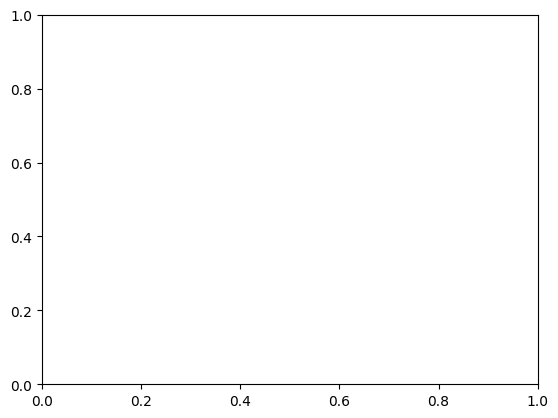

In [ ]:
sns.kdeplot(tr_lin, label="Tissue Matched", wecolor="orange", fill=True)
sns.kdeplot(tr_lin_rand, label="Random", color="blue", fill=True)

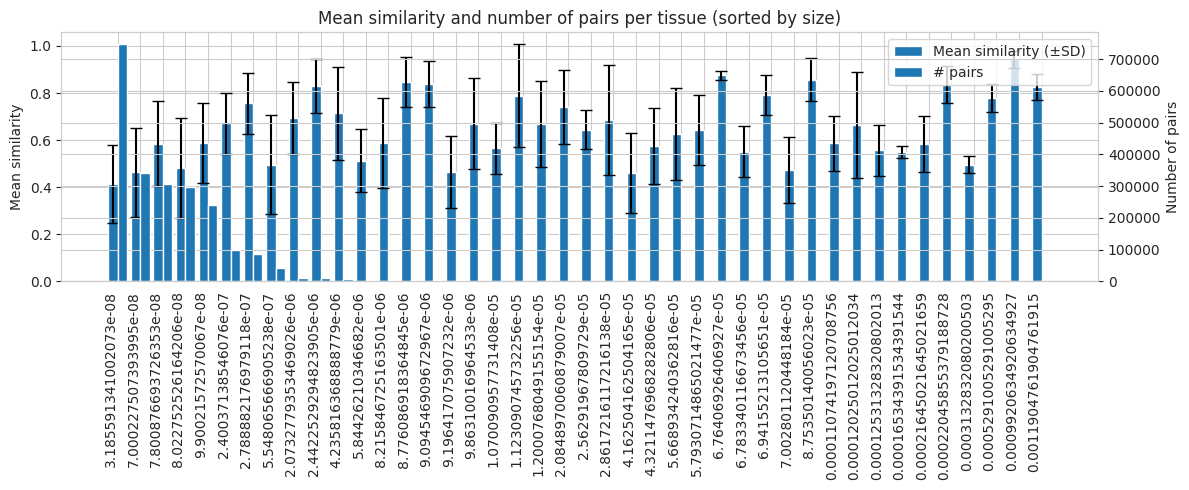

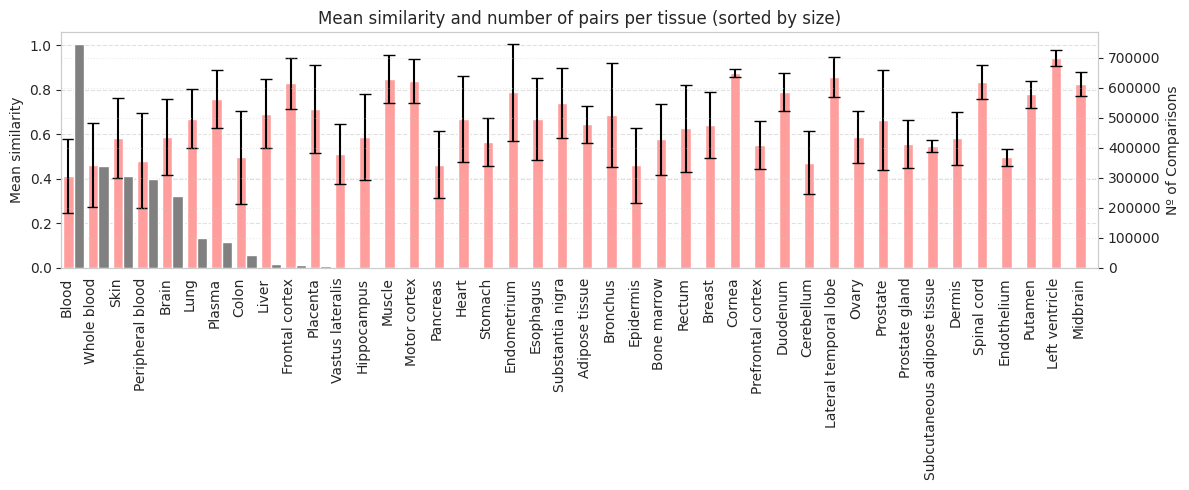

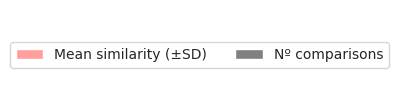

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tr_l = np.array(tr_l)
tr_s_tiss = np.array(tr_s_tiss)

assert len(tr_s_tiss) == len(tr_l), "tr_s_tiss and tr_l must have the same length"



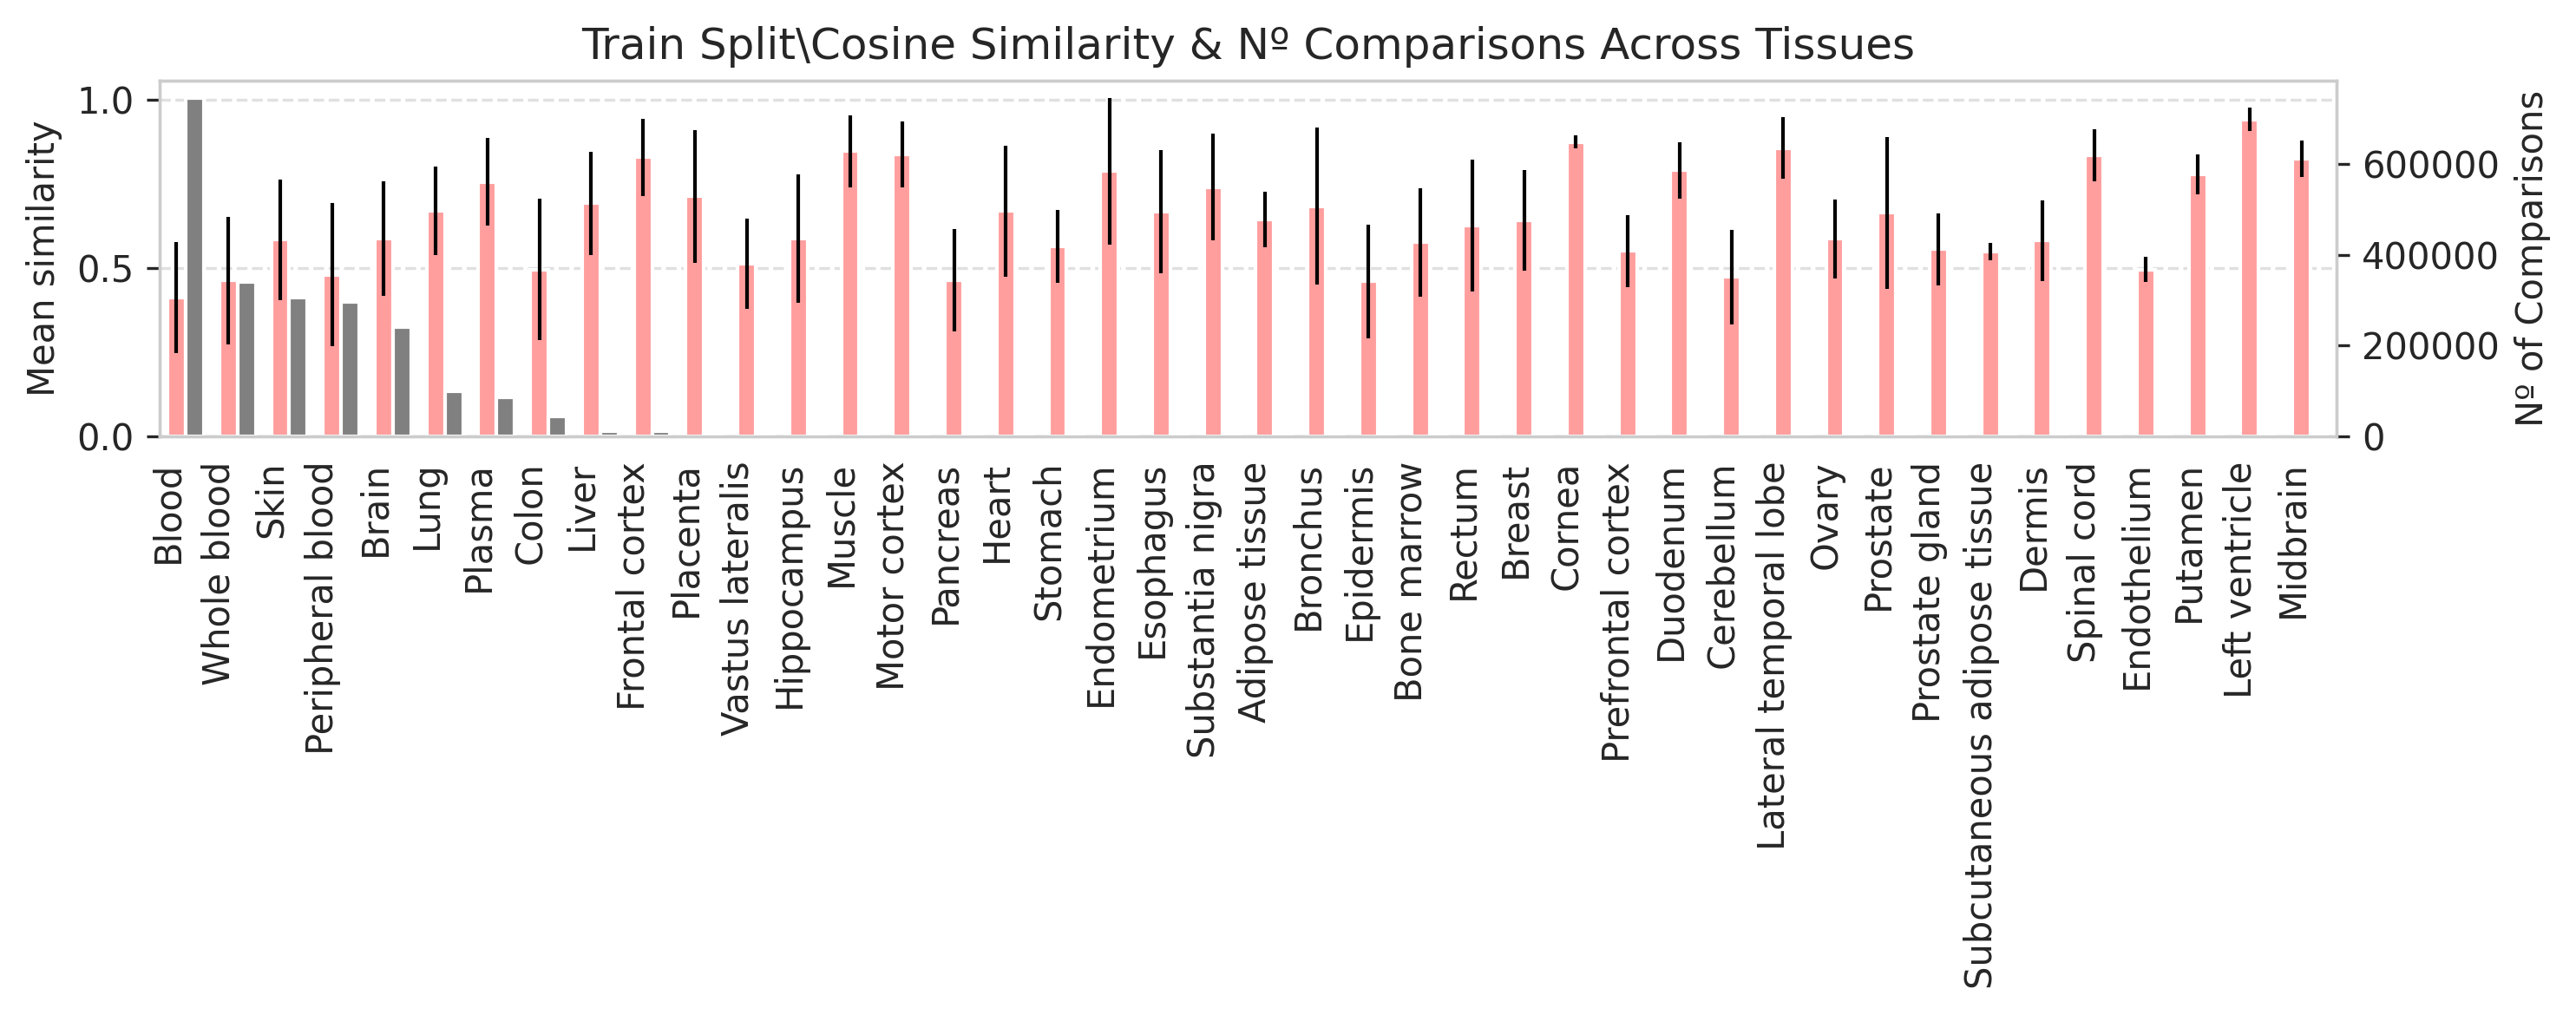

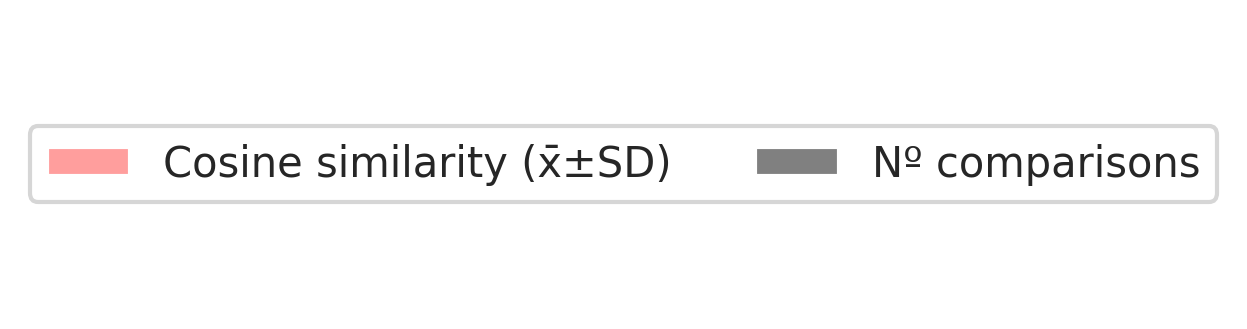

In [ ]:
tr_idx, tr_w = get_tiss_idxs_pairs(df_train["tissue"].unique().to_list(),
                   df_train["tissue"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   return_weights=True)

vl_idx, vl_w = get_tiss_idxs_pairs_split(df_valid["tissue"].unique().to_list(),
                   df_valid["tissue"].to_numpy(),
                   df_train["tissue"].to_numpy(),
                   df_valid["dataset"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   return_weights=True)


ts_idx, ts_w = get_tiss_idxs_pairs_split(df_test["tissue"].unique().to_list(),
                   df_test["tissue"].to_numpy(),
                   df_train["tissue"].to_numpy(),
                   df_test["dataset"].to_numpy(),
                   df_train["dataset"].to_numpy(),
                   return_weights=True)

/tmp/ipykernel_1958960/3363929146.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  tr_idx, tr_w = get_tiss_idxs_pairs(df_train["tissue"].unique().to_list(),
100%|██████████| 111/111 [00:00<00:00, 212.31it/s]
/tmp/ipykernel_1958960/3363929146.py:6: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  vl_idx, vl_w = get_tiss_idxs_pairs_split(df_valid["tissue"].unique().to_list(),
100%|██████████| 97/97 [00:00<00:00, 845.68it/s]
/tmp/ipykernel_1958960/3363929146.py:14: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  ts_idx, ts_w = get_tiss_idxs_pairs_split(df_test["tissue"].unique().to_list(),
100%|██████████| 38/38 [00:00<00:00, 196.89it/s]


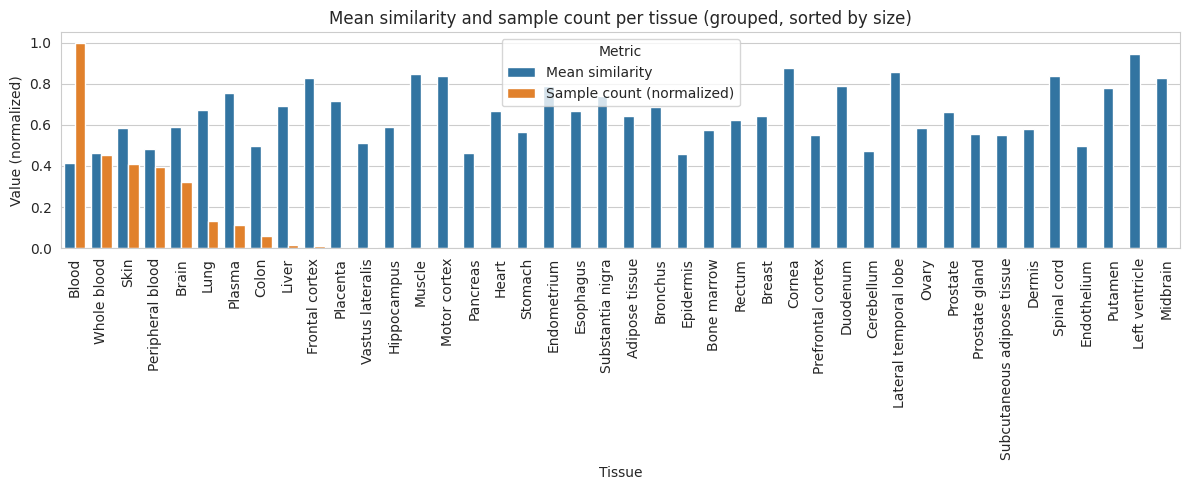

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inputs:
# tr_w: array-like tissue labels (len = n)
# tr_s_tiss: array-like similarity values (len = n)

tr_w = np.array(tr_w)
tr_s_tiss = np.array(tr_s_tiss)

assert len(tr_w) == len(tr_s_tiss), "tr_w and tr_s_tiss must have the same length"

# Build dataframe
df = pd.DataFrame({
    "tissue": tr_w,
    "similarity": tr_s_tiss
})

# Aggregate by tissue
agg = (
    df.groupby("tissue")
      .agg(
          mean_similarity=("similarity", "mean"),
          std_similarity=("similarity", "std"),
          count=("similarity", "size")
      )
      .reset_index()
)

# Sort by size (count)
agg = agg.sort_values("count", ascending=False).reset_index(drop=True)

# Normalize counts so it can share the same y-axis scale as similarity
agg["count_norm"] = agg["count"] / agg["count"].max()

# Long-form for seaborn (hue)
plot_df = agg.melt(
    id_vars="tissue",
    value_vars=["mean_similarity", "count_norm"],
    var_name="metric",
    value_name="value"
)

plot_df["metric"] = plot_df["metric"].map({
    "mean_similarity": "Mean similarity",
    "count_norm": "Sample count (normalized)"
})

# Plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=plot_df,
    x="tissue",
    y="value",
    hue="metric"
)

ax.set_title("Mean similarity and sample count per tissue (grouped, sorted by size)")
ax.set_xlabel("Tissue")
ax.set_ylabel("Value (normalized)")
plt.xticks(rotation=90, ha="center")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()


/tmp/ipykernel_1958960/470994434.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


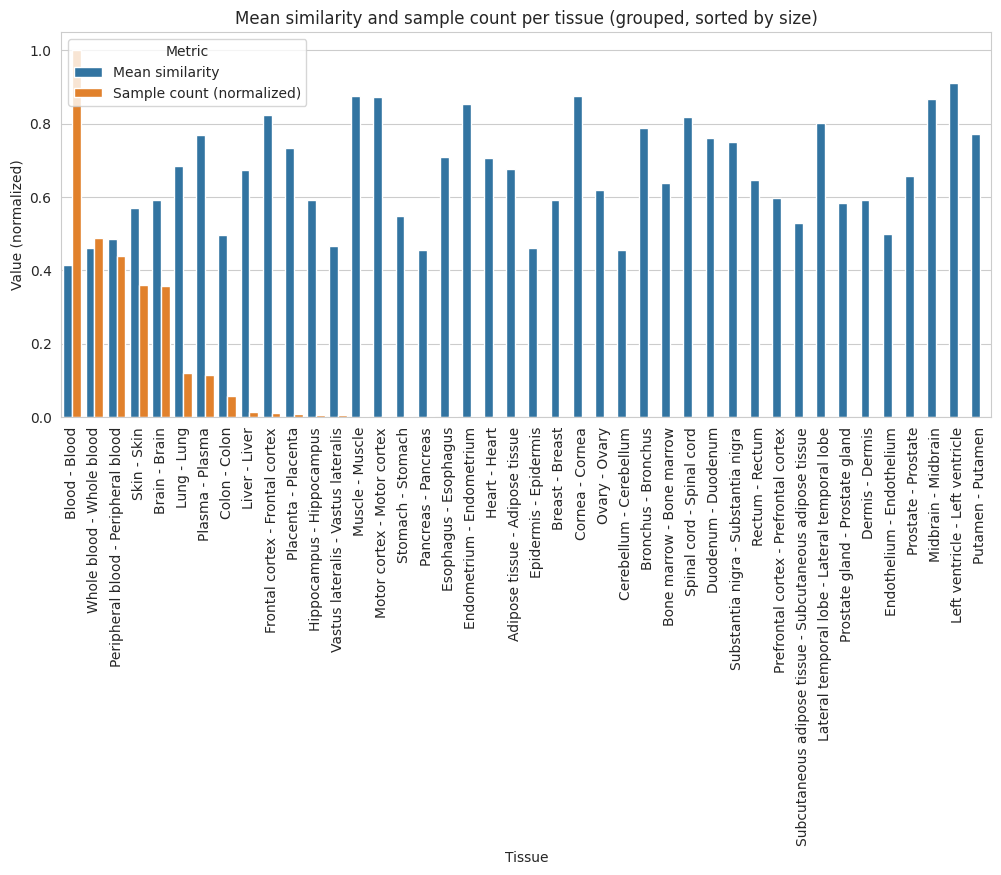

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inputs:
# vl_w: array-like tissue labels (len = n)
# vl_s_tiss: array-like similarity values (len = n)

vl_w = np.array(vl_w)
vl_s_tiss = np.array(vl_s_tiss)

assert len(vl_w) == len(vl_s_tiss), "vl_w and vl_s_tiss must have the same length"

# Build dataframe
df = pd.DataFrame({
    "tissue": vl_w,
    "similarity": vl_s_tiss
})

# Aggregate by tissue
agg = (
    df.groupby("tissue")
      .agg(
          mean_similarity=("similarity", "mean"),
          std_similarity=("similarity", "std"),
          count=("similarity", "size")
      )
      .reset_index()
)

# Sort by size (count)
agg = agg.sort_values("count", ascending=False).reset_index(drop=True)

# Normalize counts so it can share the same y-axis scale as similarity
agg["count_norm"] = agg["count"] / agg["count"].max()

# Long-form for seaborn (hue)
plot_df = agg.melt(
    id_vars="tissue",
    value_vars=["mean_similarity", "count_norm"],
    var_name="metric",
    value_name="value"
)

plot_df["metric"] = plot_df["metric"].map({
    "mean_similarity": "Mean similarity",
    "count_norm": "Sample count (normalized)"
})

# Plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=plot_df,
    x="tissue",
    y="value",
    hue="metric"
)

ax.set_title("Mean similarity and sample count per tissue (grouped, sorted by size)")
ax.set_xlabel("Tissue")
ax.set_ylabel("Value (normalized)")
plt.xticks(rotation=90, ha="center")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()


/tmp/ipykernel_1958960/1438500104.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


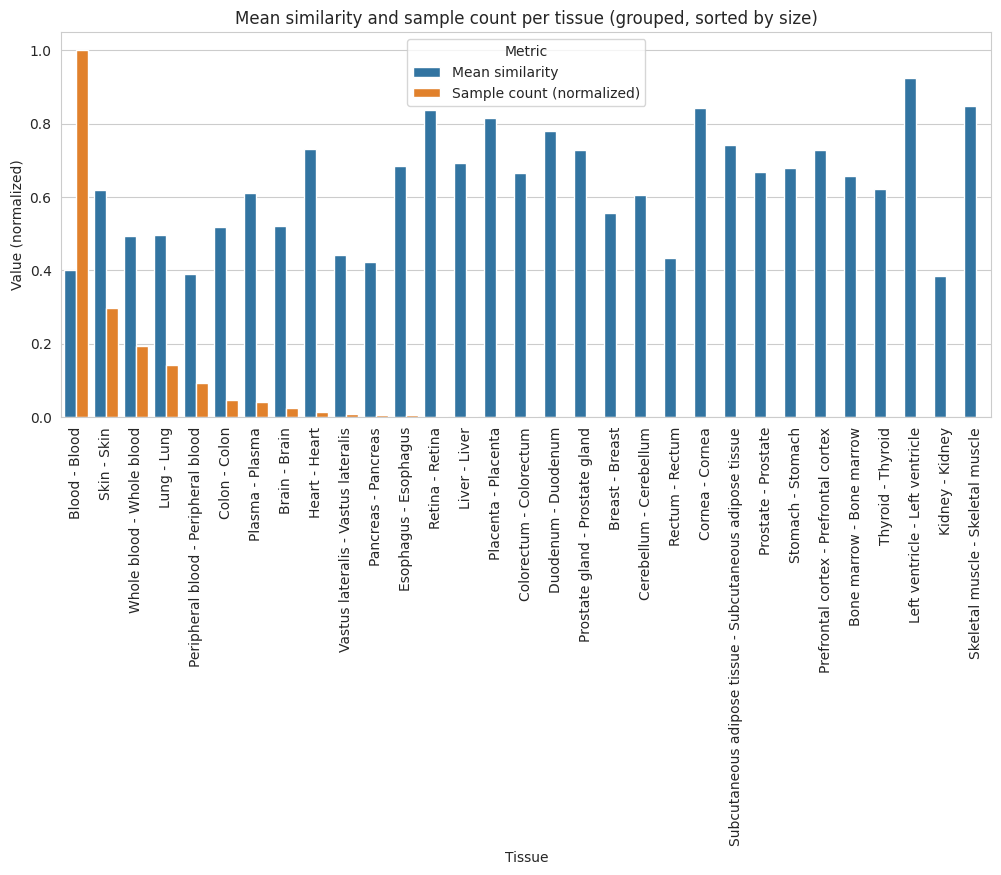

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inputs:
# ts_w: array-like tissue labels (len = n)
# ts_s_tiss: array-like similarity values (len = n)

ts_w = np.array(ts_w)
ts_s_tiss = np.array(ts_s_tiss)

assert len(ts_w) == len(ts_s_tiss), "ts_w and ts_s_tiss must have the same length"

# Build dataframe
df = pd.DataFrame({
    "tissue": ts_w,
    "similarity": ts_s_tiss
})

# Aggregate by tissue
agg = (
    df.groupby("tissue")
      .agg(
          mean_similarity=("similarity", "mean"),
          std_similarity=("similarity", "std"),
          count=("similarity", "size")
      )
      .reset_index()
)

# Sort by size (count)
agg = agg.sort_values("count", ascending=False).reset_index(drop=True)

# Normalize counts so it can share the same y-axis scale as similarity
agg["count_norm"] = agg["count"] / agg["count"].max()

# Long-form for seaborn (hue)
plot_df = agg.melt(
    id_vars="tissue",
    value_vars=["mean_similarity", "count_norm"],
    var_name="metric",
    value_name="value"
)

plot_df["metric"] = plot_df["metric"].map({
    "mean_similarity": "Mean similarity",
    "count_norm": "Sample count (normalized)"
})

# Plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=plot_df,
    x="tissue",
    y="value",
    hue="metric"
)

ax.set_title("Mean similarity and sample count per tissue (grouped, sorted by size)")
ax.set_xlabel("Tissue")
ax.set_ylabel("Value (normalized)")
plt.xticks(rotation=90, ha="center")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()


/tmp/ipykernel_1958960/433741804.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(agg["tissue"], rotation=90, ha="center")


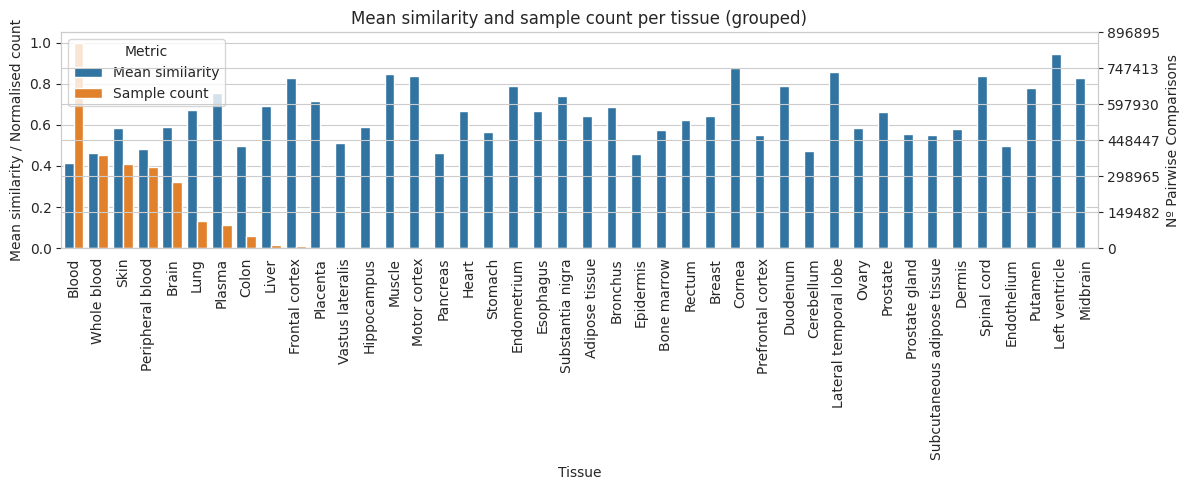

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inputs
tr_l = np.array(tr_l)
tr_s_tiss = np.array(tr_s_tiss)

assert len(tr_l) == len(tr_s_tiss)

# Build dataframe
df = pd.DataFrame({
    "tissue": tr_l,
    "similarity": tr_s_tiss
})

# Aggregate
agg = (
    df.groupby("tissue")
      .agg(
          mean_similarity=("similarity", "mean"),
          std_similarity=("similarity", "std"),
          count=("similarity", "size")
      )
      .reset_index()
)

# Sort by size
agg = agg.sort_values("count", ascending=False).reset_index(drop=True)

# Normalise counts for plotting
max_count = agg["count"].max()
agg["count_norm"] = agg["count"] / max_count

# Long format
plot_df = agg.melt(
    id_vars="tissue",
    value_vars=["mean_similarity", "count_norm"],
    var_name="metric",
    value_name="value"
)

plot_df["metric"] = plot_df["metric"].map({
    "mean_similarity": "Mean similarity",
    "count_norm": "Sample count"
})

# Plot
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=plot_df,
    x="tissue",
    y="value",
    hue="metric",
    ax=ax1
)

# Axis labels
ax1.set_xlabel("Tissue")
ax1.set_ylabel("Mean similarity / Normalised count")
ax1.set_title("Mean similarity and sample count per tissue (grouped)")
ax1.set_xticklabels(agg["tissue"], rotation=90, ha="center")

# ---- SECOND Y AXIS (REAL COUNTS) ----
ax2 = ax1.twinx()
ax2.set_ylim(0, max_count)
ax2.set_ylabel("Nº Pairwise Comparisons")

# Make sure tick positions align with normalised scale
ticks = ax1.get_yticks()
ax2.set_yticks(ticks * max_count)
ax2.set_yticklabels([f"{int(t)}" for t in ticks * max_count])

# Legend
ax1.legend(title="Metric")

plt.tight_layout()
plt.show()
